In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd 
import os

temp_data = []

temp_data.append(kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "priyankabarik/chronic-kidney-disease-ckd-clinical-dataset",
    "Testing_CKD_dataset.csv",
    ))

temp_data.append(kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "priyankabarik/chronic-kidney-disease-ckd-clinical-dataset",
    "Training_CKD_dataset.csv",
    ))

df = pd.concat(temp_data)

Download already complete (3998668 bytes).


In [5]:
df

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,38,0,33,114,78,78,0,10,117,...,97,4.677411,211,203,4,5.156141,No,No,Yes,No
1,Severe CKD (Stage 4),76,0,28,166,103,92,5,84,25,...,111,9.490302,194,210,2,7.922118,No,No,No,No
2,Healthy Kidney,63,0,33,109,79,98,0,17,109,...,125,6.023745,243,138,4,6.606848,No,No,No,Yes
3,Healthy Kidney,54,0,31,107,62,109,0,10,107,...,127,5.772014,163,276,4,6.651897,No,Yes,No,Yes
4,Healthy Kidney,20,0,20,111,63,92,0,17,97,...,127,8.483288,221,264,4,6.400641,No,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,Healthy Kidney,45,0,19,98,62,86,0,11,115,...,124,6.337256,255,275,4,6.536640,No,No,No,No
20996,Mild CKD (Stage 1–2),82,0,20,125,81,88,1,24,70,...,121,4.149633,207,297,3,6.707196,Yes,Yes,Yes,No
20997,Healthy Kidney,65,0,23,119,62,95,0,19,105,...,110,5.738345,249,196,4,6.576637,Yes,No,Yes,No
20998,Healthy Kidney,63,0,18,117,69,76,0,7,109,...,95,7.386147,278,231,4,6.030633,No,No,Yes,Yes


In [1]:

path = kagglehub.dataset_download("priyankabarik/chronic-kidney-disease-ckd-clinical-dataset")
print("Path to dataset files:", path)

100%|██████████| 1.89M/1.89M [00:00<00:00, 4.33MB/s]

Extracting model files...
Path to dataset files: C:\Users\Tasin\.cache\kagglehub\datasets\priyankabarik\chronic-kidney-disease-ckd-clinical-dataset\versions\1


# Step 1 - EDA¶


### The data exhibits a rich mix of both numerical and categorical features.



In [2]:
df

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,Healthy Kidney,63,0,24,103,78,91,0,13,90,...,109,9.231548,261,249,4,6.740736,No,Yes,No,No
4796,Healthy Kidney,79,1,21,101,74,95,0,18,118,...,97,7.085726,166,187,4,5.675948,No,No,Yes,Yes
4797,Mild CKD (Stage 1–2),82,1,26,127,85,93,1,24,84,...,82,9.145745,268,139,3,6.410811,Yes,No,Yes,Yes
4798,Healthy Kidney,24,1,32,99,61,84,0,17,94,...,98,9.126159,174,161,4,7.071250,No,Yes,No,No


Converted **Gender** to categorical. 

In [3]:
df['Gender'] = df['Gender'].astype("object")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25800 entries, 0 to 4799
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    25800 non-null  object 
 1   Age                       25800 non-null  int64  
 2   Gender                    25800 non-null  object 
 3   BMI                       25800 non-null  int64  
 4   Systolic_BP               25800 non-null  int64  
 5   Diastolic_BP              25800 non-null  int64  
 6   Heart_Rate                25800 non-null  int64  
 7   Serum_Creatinine          25800 non-null  int64  
 8   Blood_Urea_Nitrogen       25800 non-null  int64  
 9   eGFR                      25800 non-null  int64  
 10  Urine_Albumin             25800 non-null  int64  
 11  Urine_Protein             25800 non-null  int64  
 12  Albumin_Creatinine_Ratio  25800 non-null  int64  
 13  Urine_Specific_Gravity    25800 non-null  float64
 14  Sodium      

The **Target** field is what our model needs to predict. It is categorical and has the following options:

* Healthy Kidney
* Mild CKD (Stage 1–2)
* Moderate CKD (Stage 3)
* Severe CKD (Stage 4)
* Kidney Failure (Stage 5)

In [4]:
df['Target'].unique()

array(['Healthy Kidney', 'Severe CKD (Stage 4)', 'Mild CKD (Stage 1–2)',
       'Moderate CKD (Stage 3)', 'Kidney Failure (Stage 5)'], dtype=object)

In [5]:
print((df.isnull().sum()/(len(df)))*100)
print("There are no null values.")

Target                      0.0
Age                         0.0
Gender                      0.0
BMI                         0.0
Systolic_BP                 0.0
Diastolic_BP                0.0
Heart_Rate                  0.0
Serum_Creatinine            0.0
Blood_Urea_Nitrogen         0.0
eGFR                        0.0
Urine_Albumin               0.0
Urine_Protein               0.0
Albumin_Creatinine_Ratio    0.0
Urine_Specific_Gravity      0.0
Sodium                      0.0
Potassium                   0.0
Calcium                     0.0
Phosphorus                  0.0
Chloride                    0.0
Bicarbonate                 0.0
Hemoglobin                  0.0
RBC_Count                   0.0
WBC_Count                   0.0
Platelet_Count              0.0
Packed_Cell_Volume          0.0
Blood_Glucose_Random        0.0
Fasting_Glucose             0.0
HbA1c                       0.0
Cholesterol                 0.0
Triglycerides               0.0
Serum_Albumin               0.0
Total_Pr

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25800.0,51.967752,18.795514,20.000000,36.000000,52.000000,68.000000,84.000000
BMI,25800.0,25.981899,4.901244,18.000000,22.000000,26.000000,30.000000,34.000000
Systolic_BP,25800.0,113.454070,19.127432,90.000000,99.000000,109.000000,119.000000,189.000000
Diastolic_BP,25800.0,75.265465,12.084824,60.000000,66.000000,73.000000,79.000000,119.000000
Heart_Rate,25800.0,84.379651,14.385955,60.000000,72.000000,84.000000,97.000000,109.000000
Serum_Creatinine,25800.0,0.627016,1.476770,0.000000,0.000000,0.000000,0.000000,9.000000
Blood_Urea_Nitrogen,25800.0,21.671977,20.773213,7.000000,11.000000,15.000000,19.000000,149.000000
eGFR,25800.0,91.512829,26.763569,5.000000,90.000000,99.000000,110.000000,119.000000
Urine_Albumin,25800.0,59.774264,136.118637,0.000000,6.000000,13.000000,19.000000,999.000000
Urine_Protein,25800.0,31.110930,73.049288,0.000000,3.000000,6.000000,9.000000,499.000000


### I do not have a medical understanding of what the acceptable values are for each features. If there are outliers, let me know down in the comments.

Feature engineering not performed.

# Step 2 - EDA graph plot

In [7]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64']).columns
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['Target', 'Gender', 'Diabetes', 'Hypertension', 'Smoking_Status',
       'Family_History_Kidney'],
      dtype='object')
Numerical Variables:
Index(['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate',
       'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin',
       'Urine_Protein', 'Albumin_Creatinine_Ratio', 'Sodium', 'Potassium',
       'Calcium', 'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin',
       'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
       'Blood_Glucose_Random', 'Fasting_Glucose', 'Cholesterol',
       'Triglycerides', 'Serum_Albumin'],
      dtype='object')


Age
Skew : 0.0


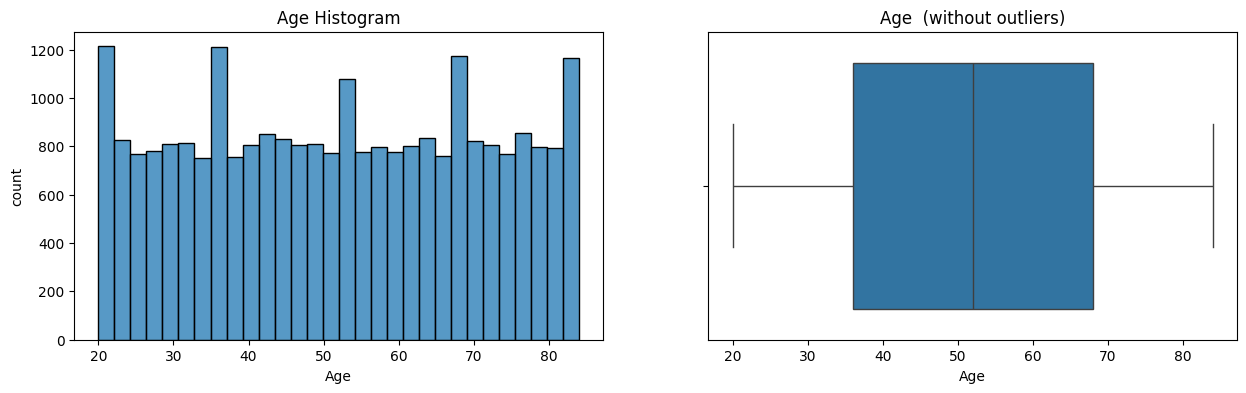

BMI
Skew : 0.0


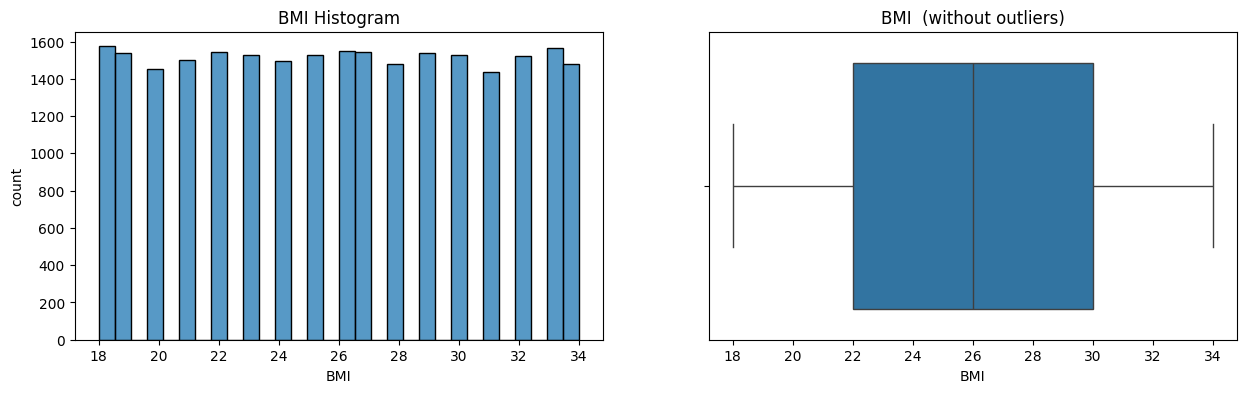

Systolic_BP
Skew : 1.32


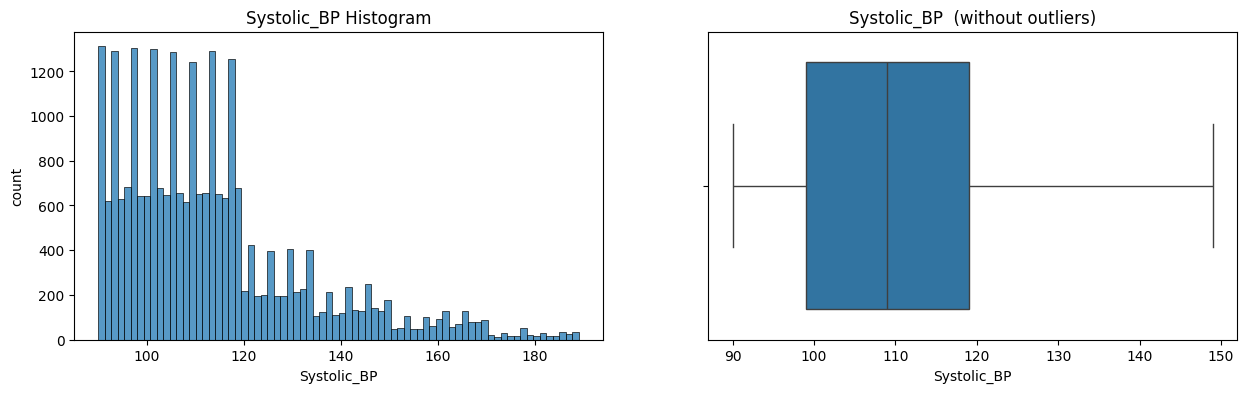

Diastolic_BP
Skew : 1.13


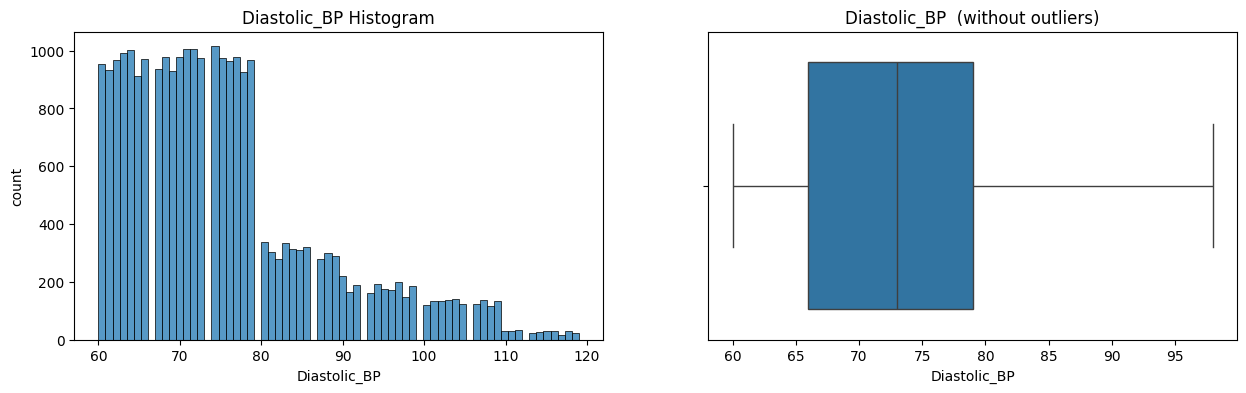

Heart_Rate
Skew : 0.01


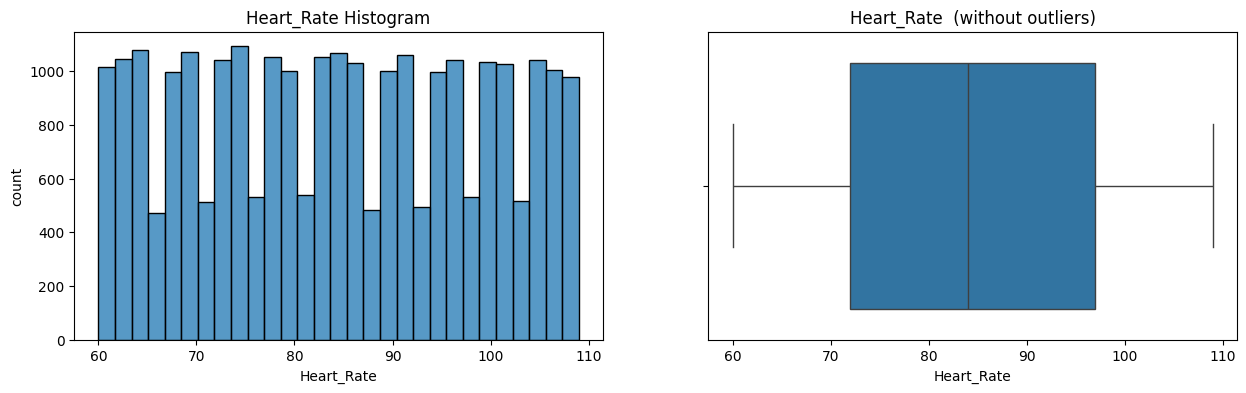

Serum_Creatinine
Skew : 3.14


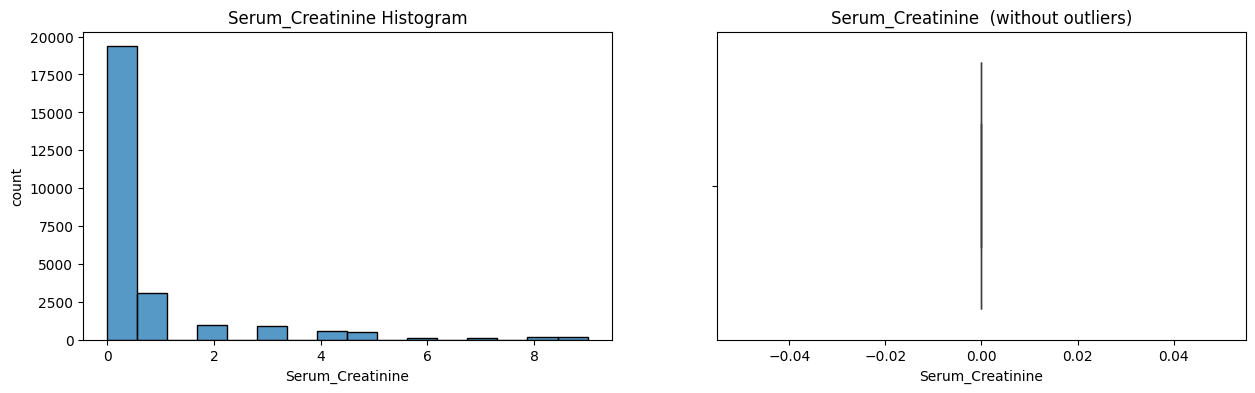

Blood_Urea_Nitrogen
Skew : 3.03


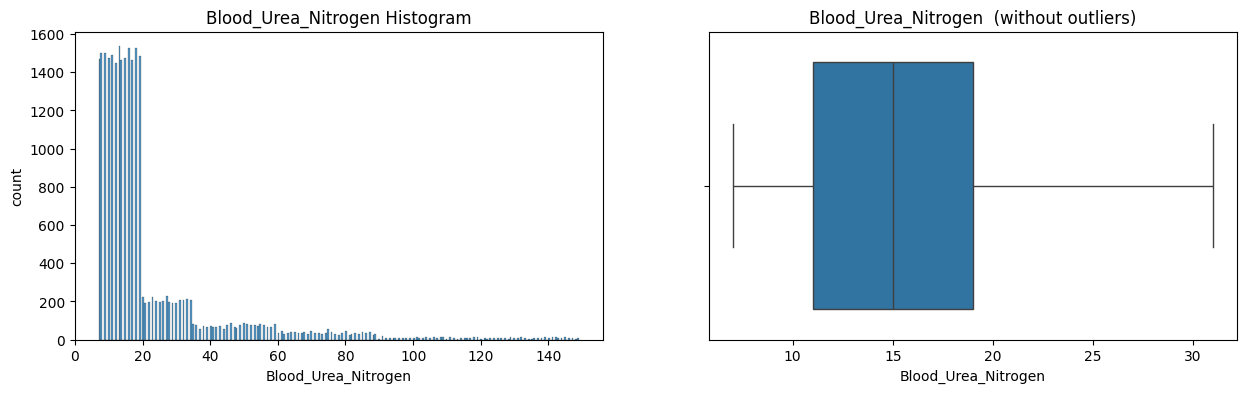

eGFR
Skew : -1.56


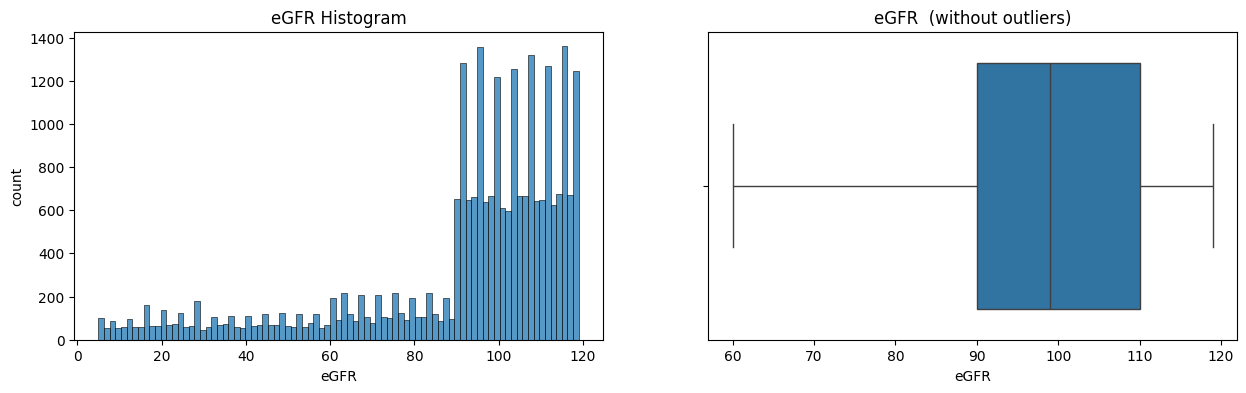

Urine_Albumin
Skew : 3.75


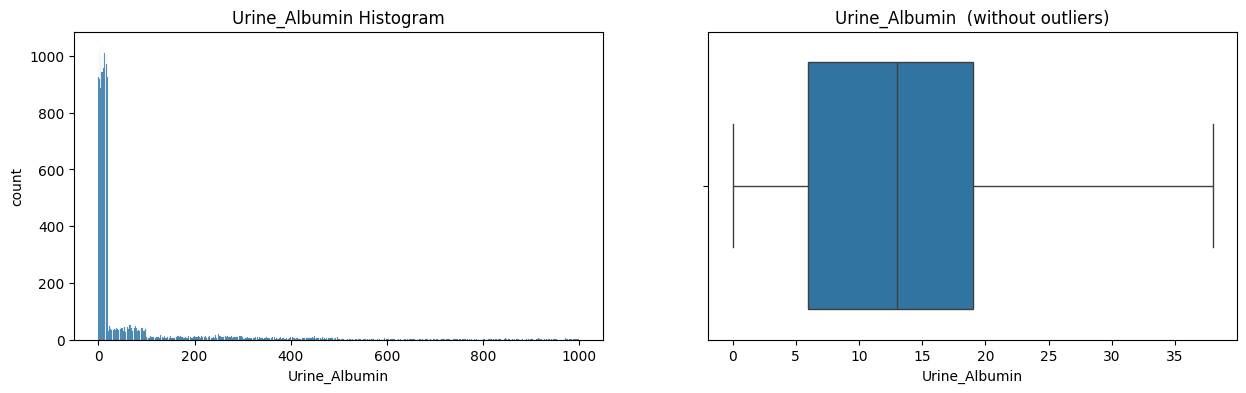

Urine_Protein
Skew : 3.69


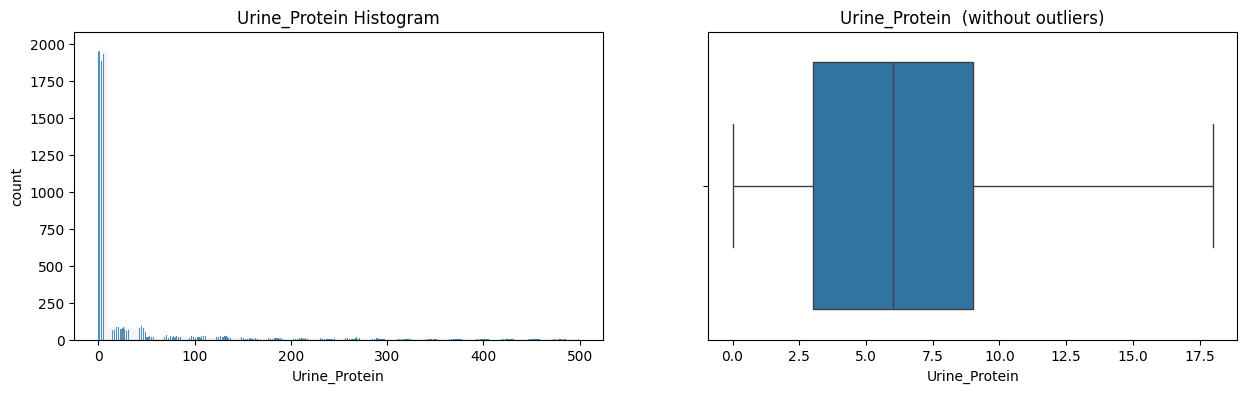

Albumin_Creatinine_Ratio
Skew : 4.11


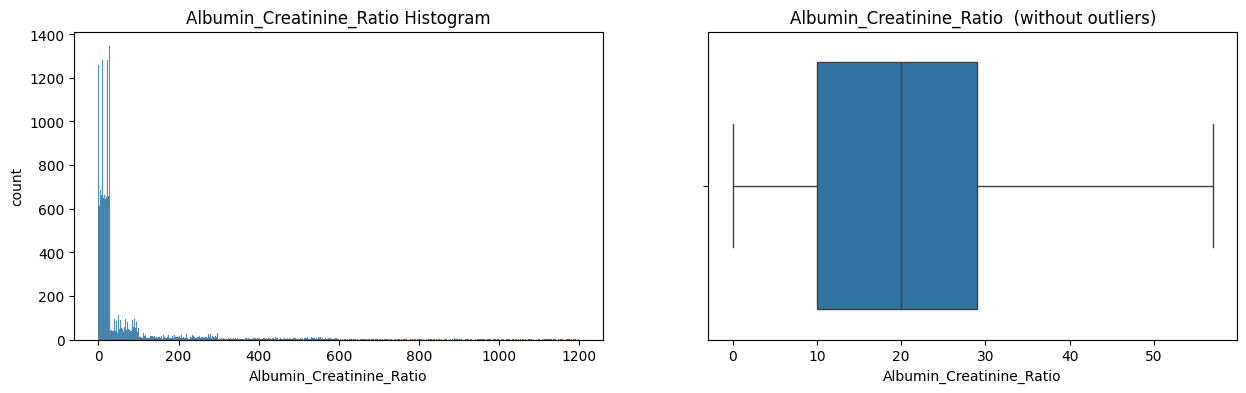

Sodium
Skew : 0.0


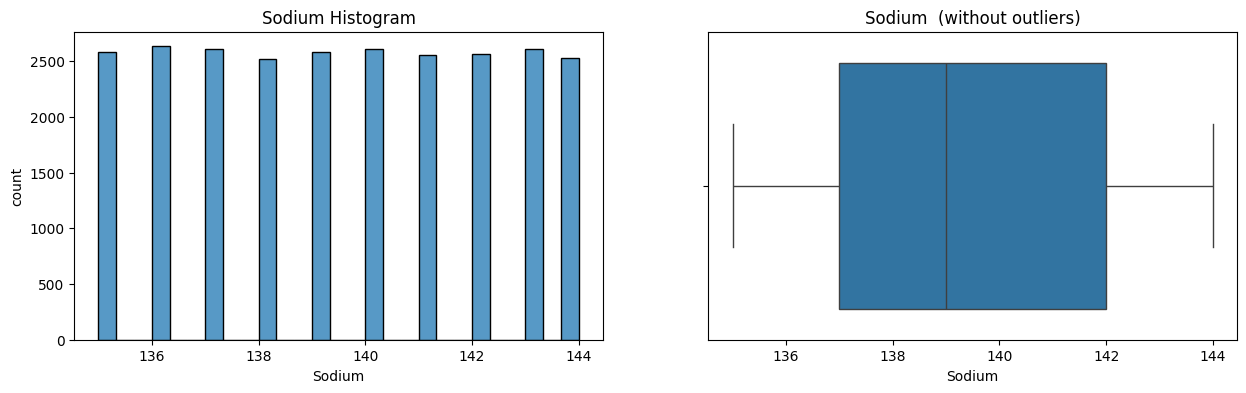

Potassium
Skew : 1.84


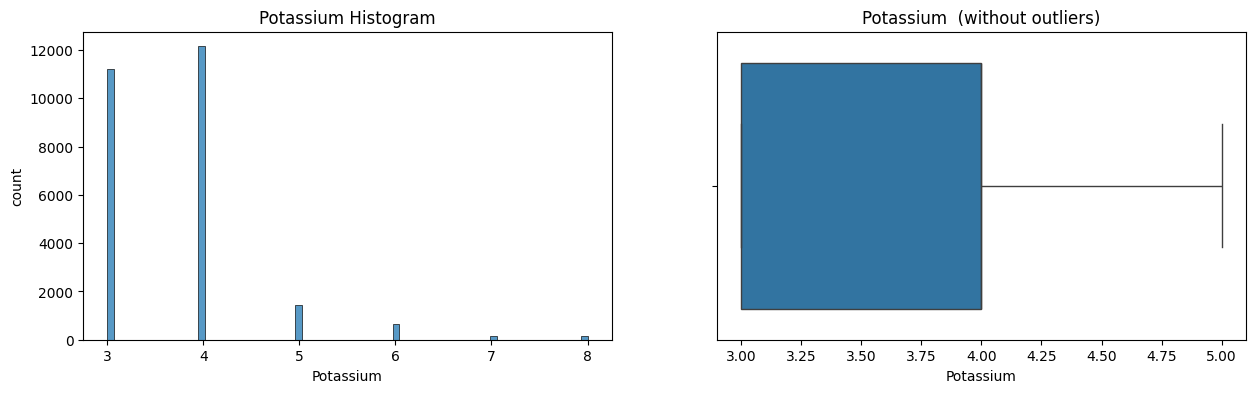

Calcium
Skew : -0.0


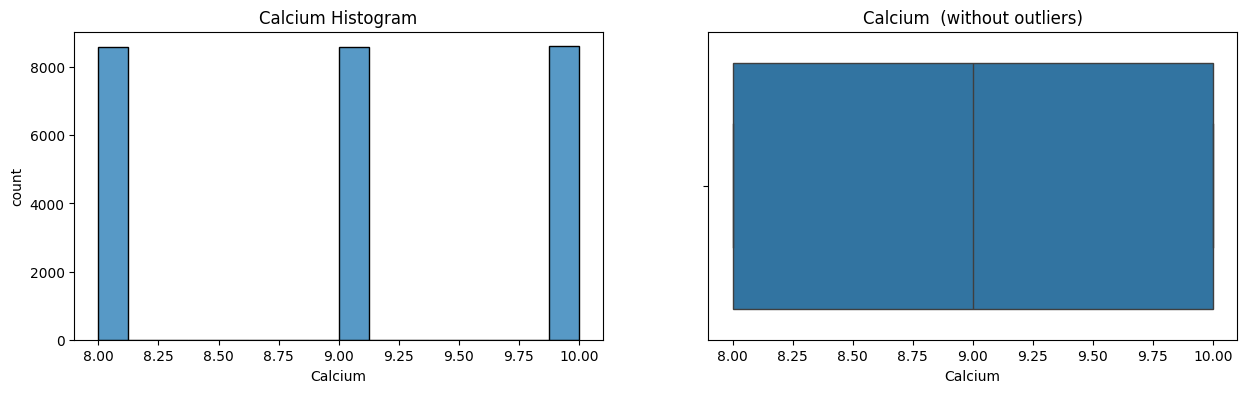

Phosphorus
Skew : 1.71


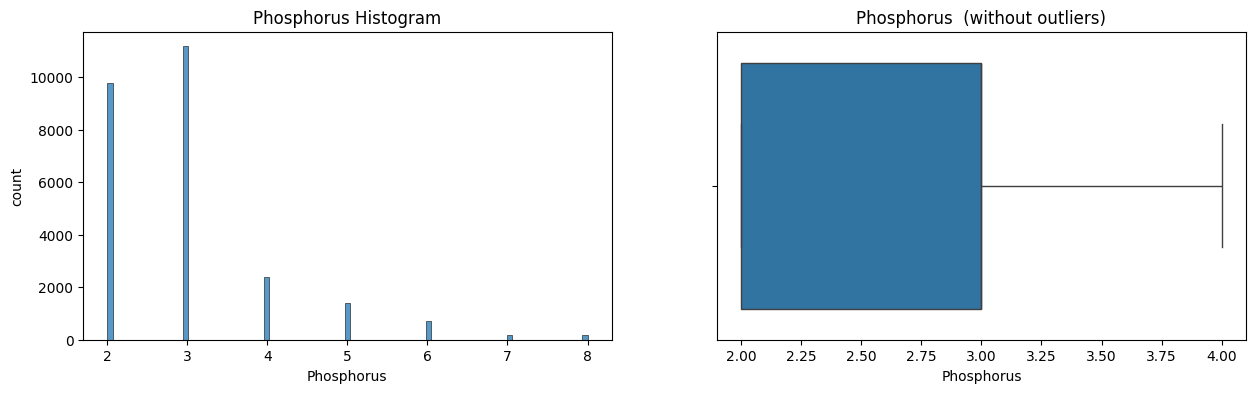

Chloride
Skew : -0.0


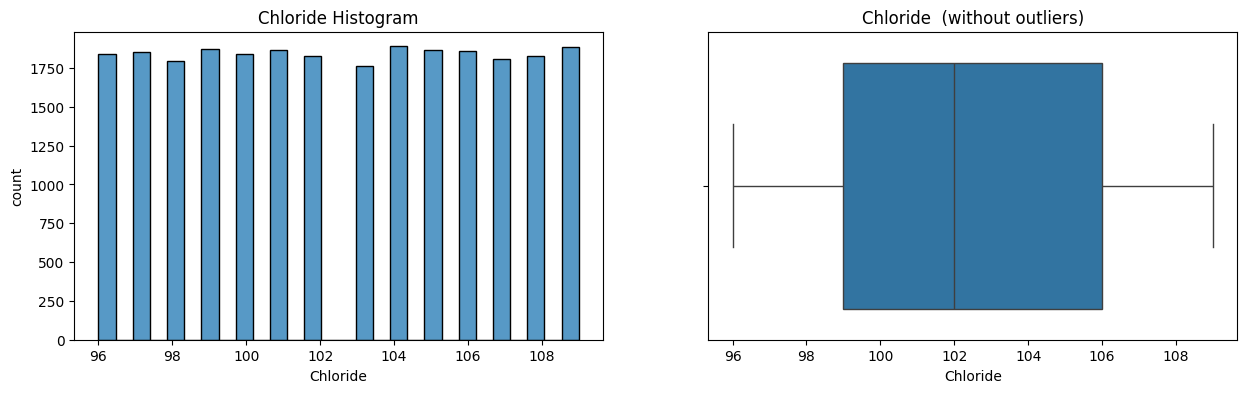

Bicarbonate
Skew : -1.21


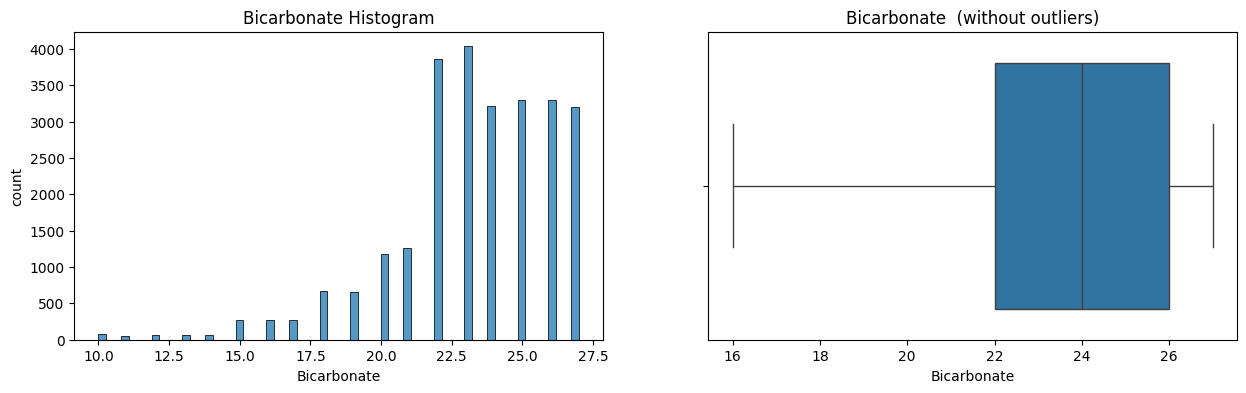

Hemoglobin
Skew : -1.29


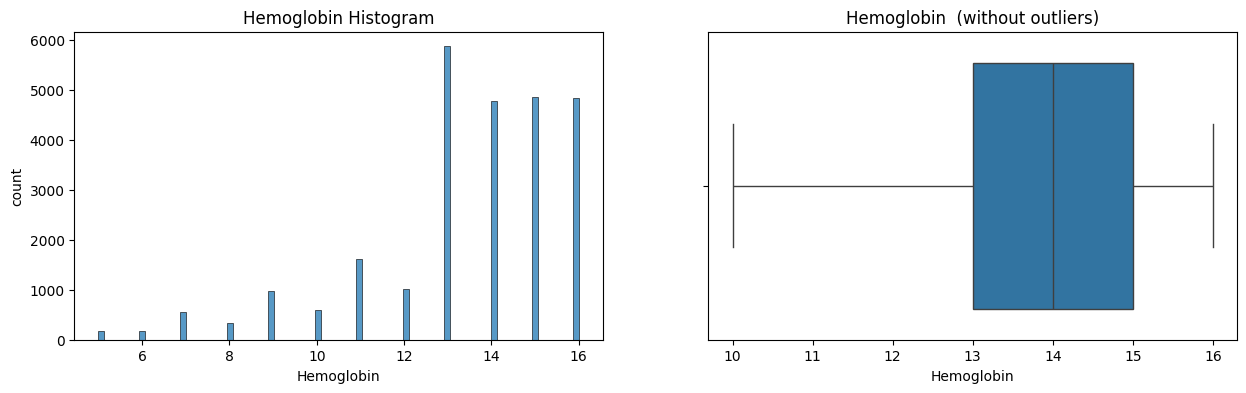

WBC_Count
Skew : -0.0


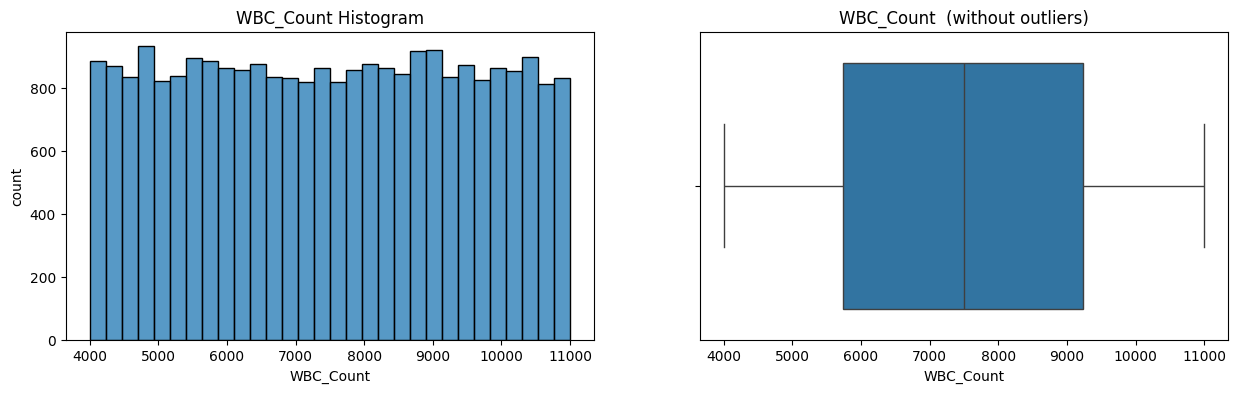

Platelet_Count
Skew : -0.01


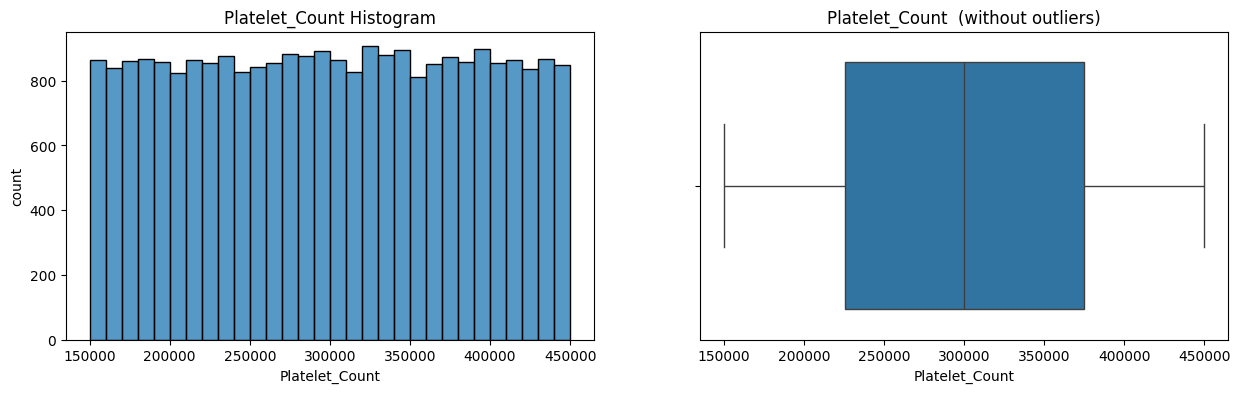

Packed_Cell_Volume
Skew : -1.31


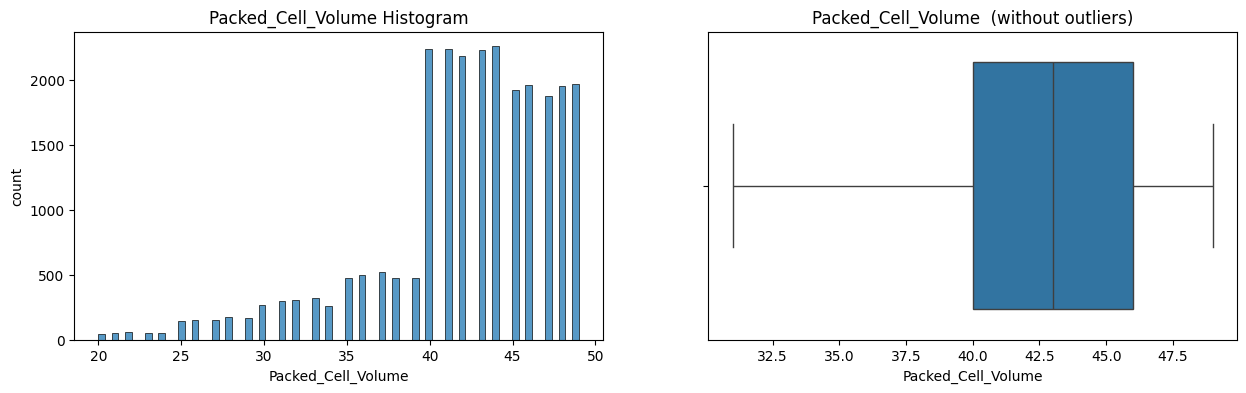

Blood_Glucose_Random
Skew : 0.0


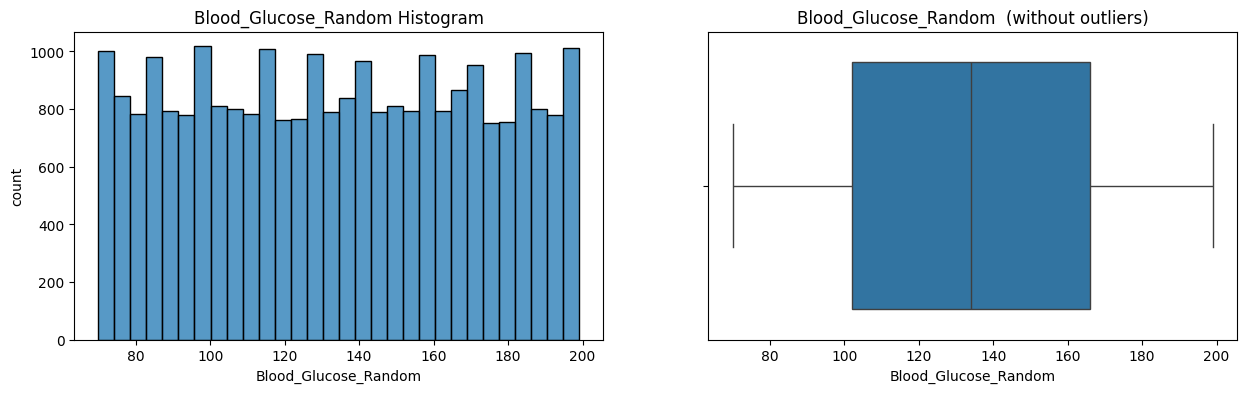

Fasting_Glucose
Skew : -0.0


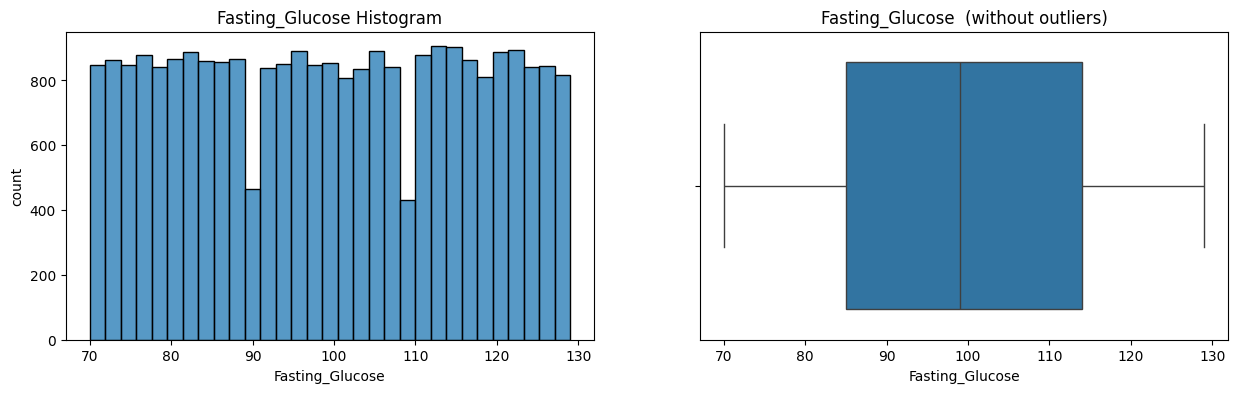

Cholesterol
Skew : -0.0


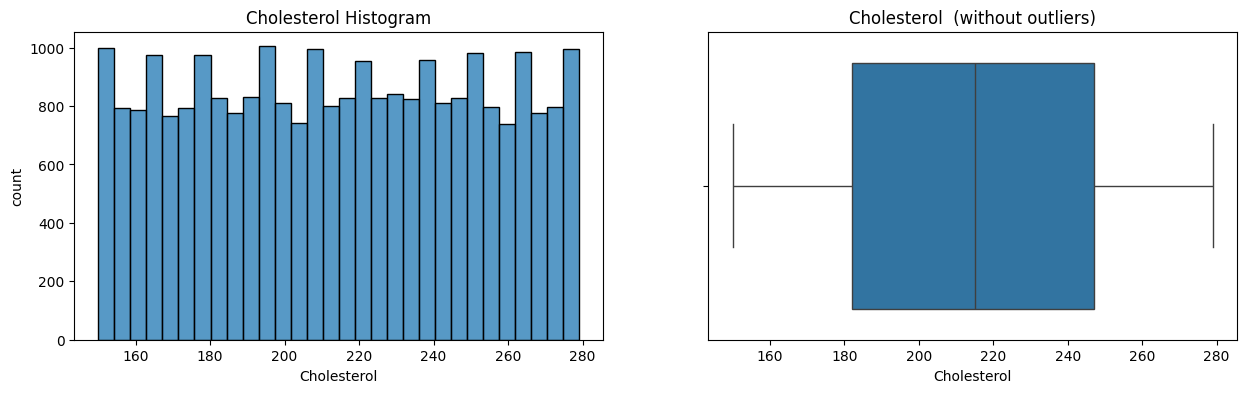

Triglycerides
Skew : -0.01


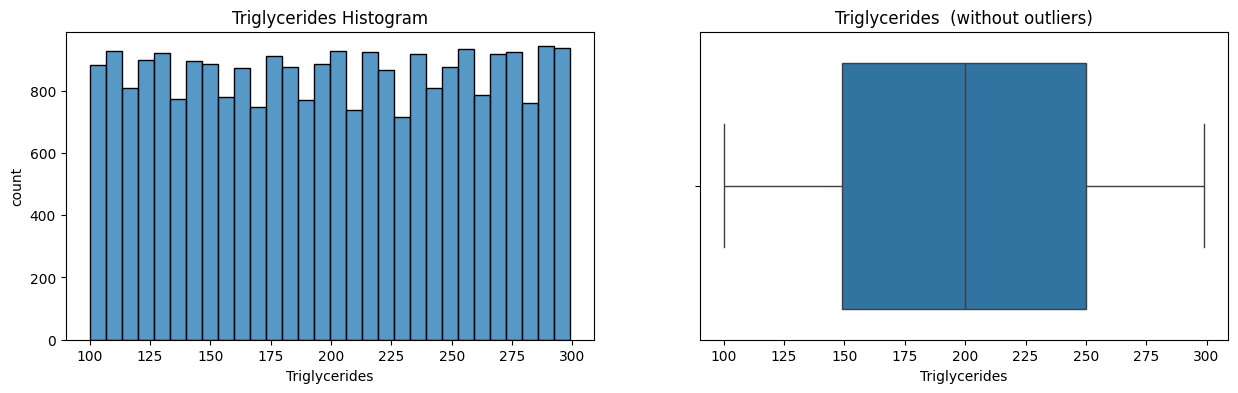

Serum_Albumin
Skew : -1.76


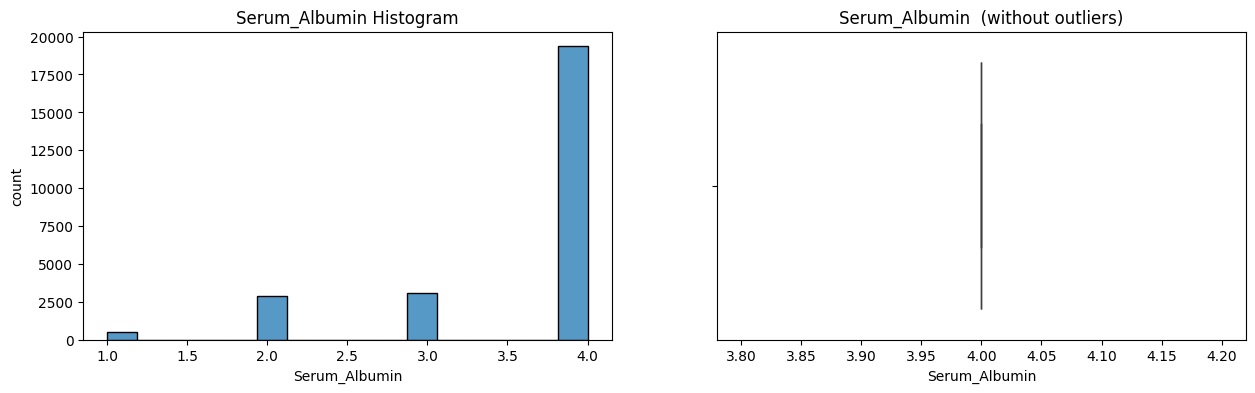

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize=(15, 4))
    
    # Histogram without outliers
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col)
    plt.ylabel('count')
    plt.title(f'{col} Histogram')
    
    # Boxplot without outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], showfliers=False)
    plt.title(f'{col}  (without outliers)')
    
    plt.show()

The medical features are highly skewed, which suggests that their relationships with the target may be non‑linear. Parametric models such as logistic regression rely on assumptions about linearity and can therefore require feature transformations to perform well. To keep this notebook short, we instead employ non‑parametric methods, which are better suited to capturing complex, non‑linear relationships without strong distributional assumptions.

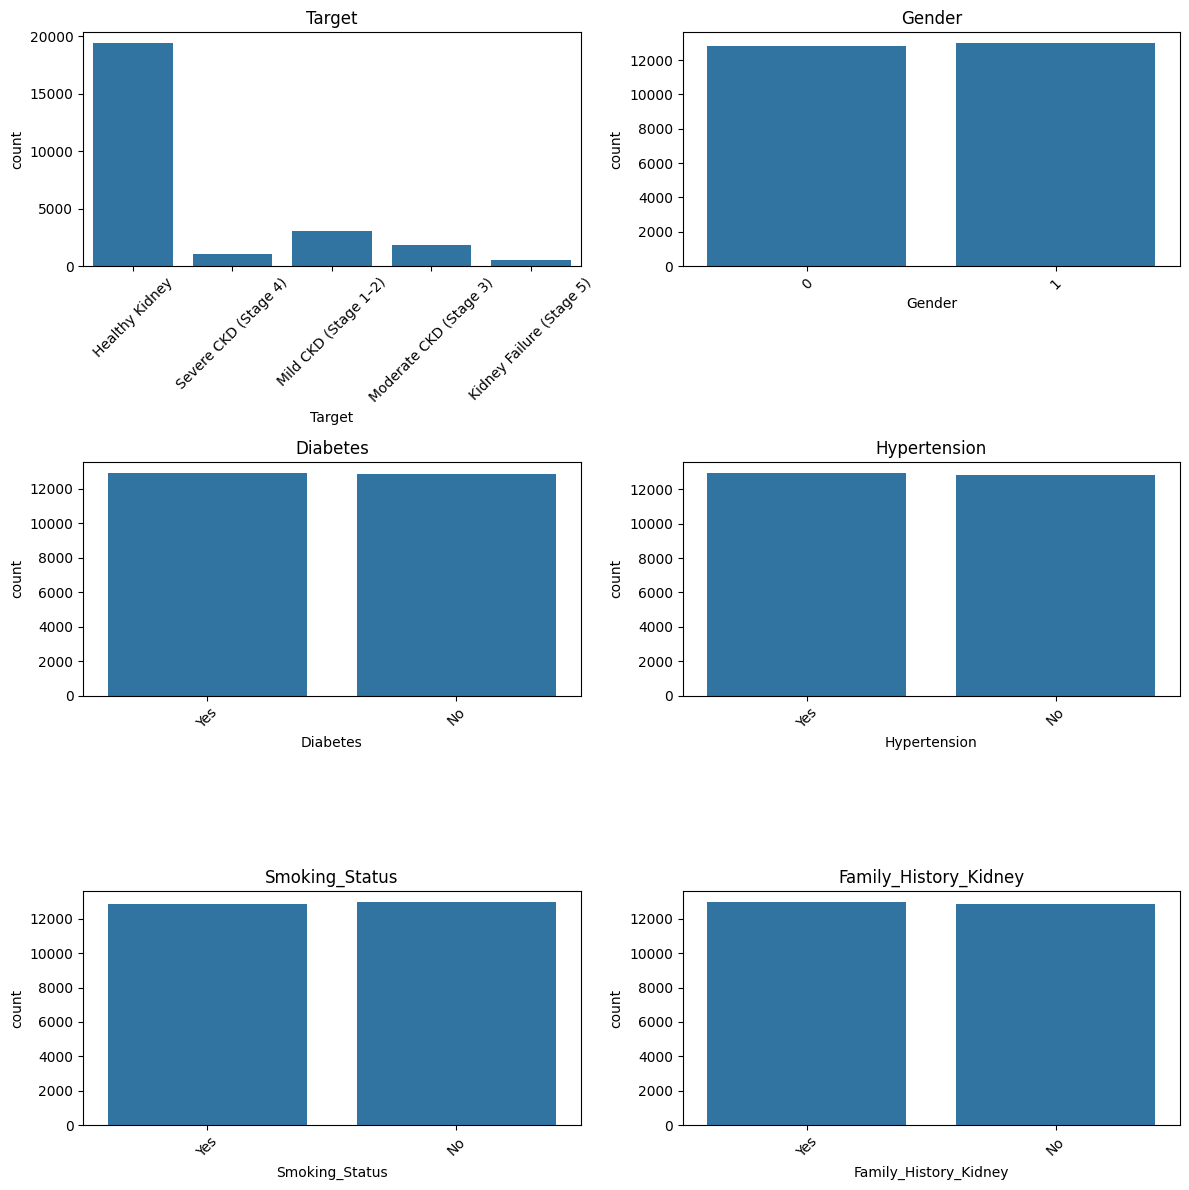

In [9]:
import math 

plots_per_row = 2

rows = math.ceil(len(cat_cols) / plots_per_row)

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

The dataset is heavily imbalanced, with most cases labelled as healthy kidneys, so care is needed when creating the training and test splits.

# Step 3 - Bivariate Analysis

/tmp/ipykernel_17/3527514182.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


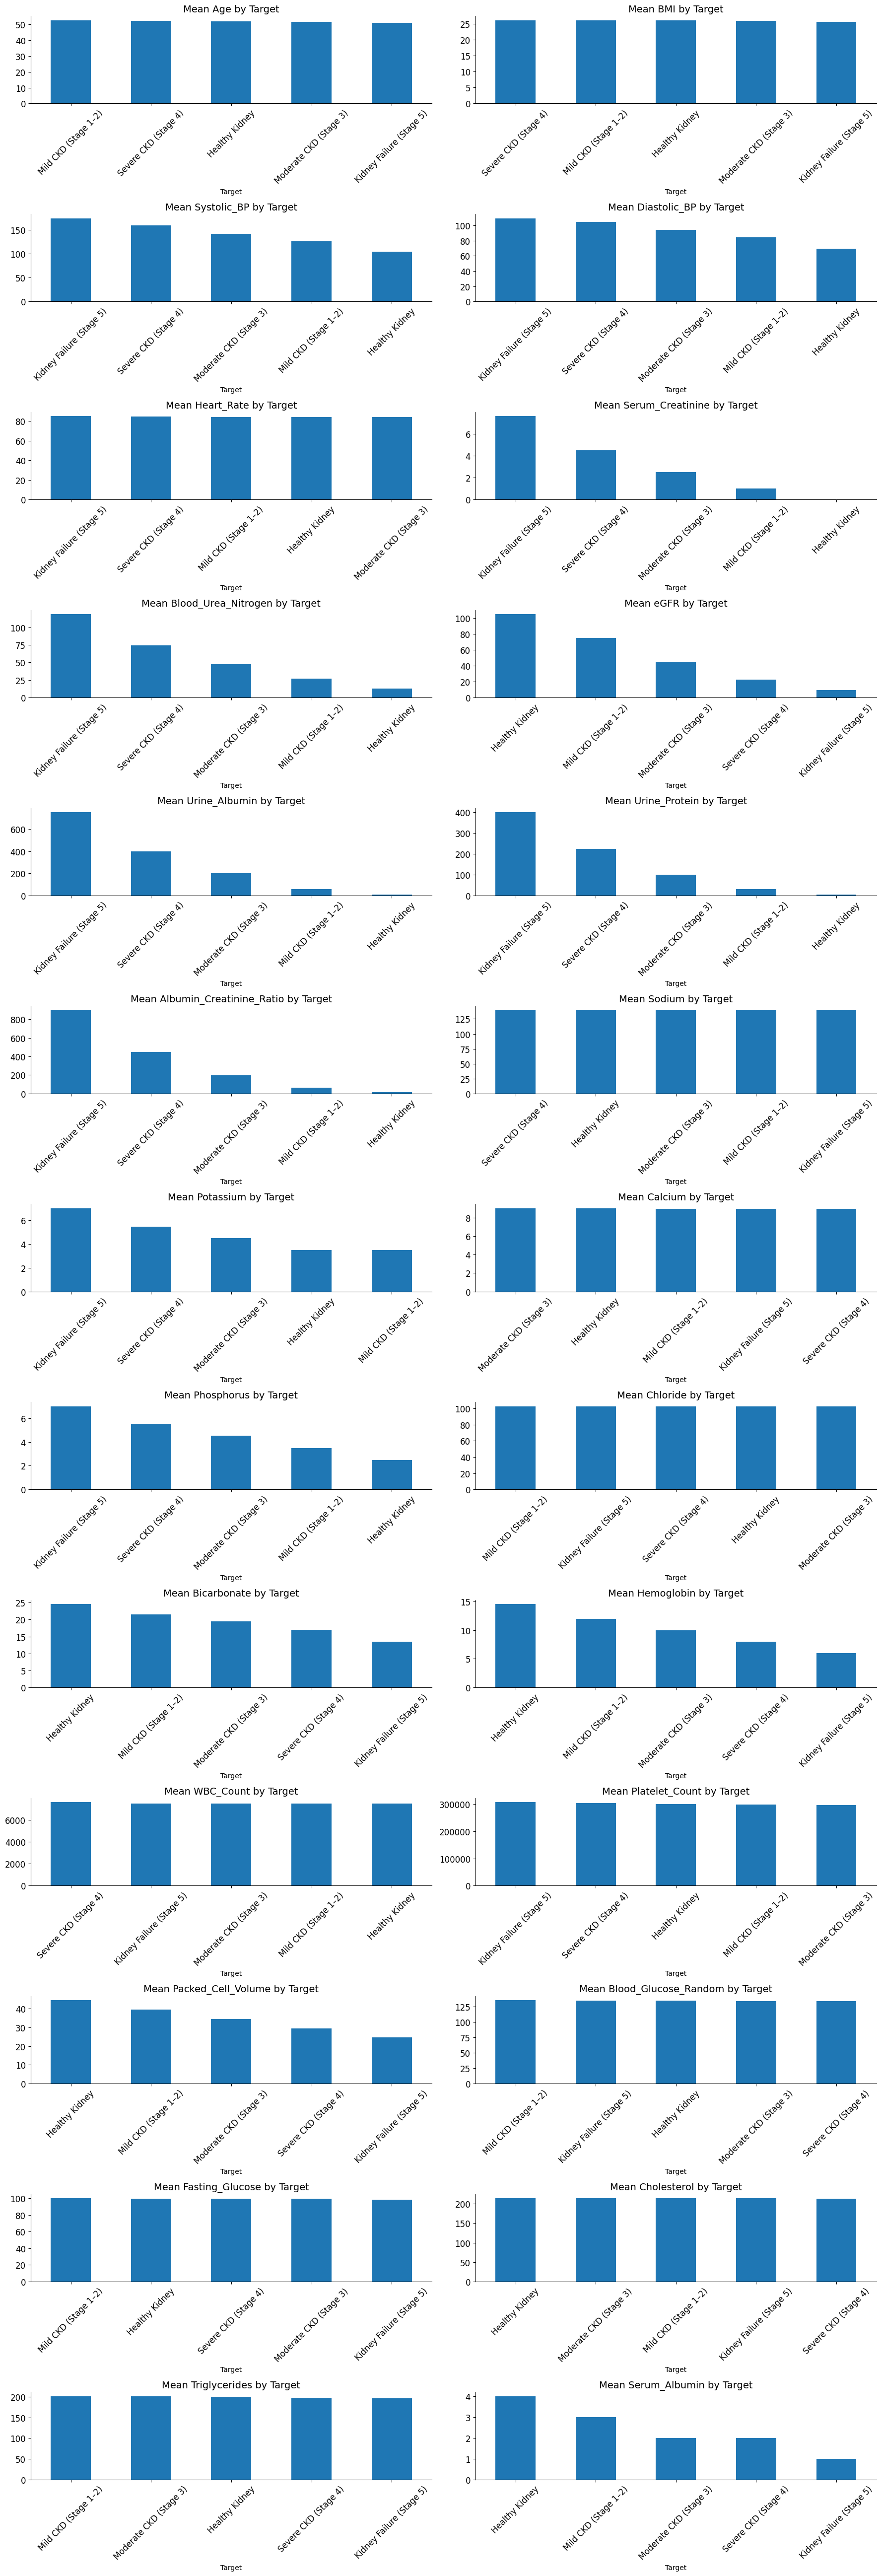

In [10]:
nrows, ncols = 13, 2

fig_h = nrows * 4.0   # try 2.4–3.0 depending on label length
fig_w = 18

fig, axarr = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), constrained_layout=True)
axes = axarr.ravel()

for i, num_col in enumerate(num_cols):
    (df.groupby('Target')[num_col]
       .mean()
       .sort_values(ascending=False)
       .plot(kind='bar', ax=axes[i], fontsize=12))

    axes[i].set_title(f"Mean {num_col} by Target", fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, nrows*ncols):
    axes[j].axis('off')

plt.tight_layout()
sns.despine()
plt.show()

Some features **strongly** indicate kidney failure. 

For example, elevated systolic and diastolic BP, serum creatinine, blood urea nitrogen, albumin, protein, and potassium levels are associated with kidney failure.

Conversely, reduced levels of eGFR, bicarbonate, haemoglobin, and serum albumin are also indicative of kidney failure.

/tmp/ipykernel_17/3041167491.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


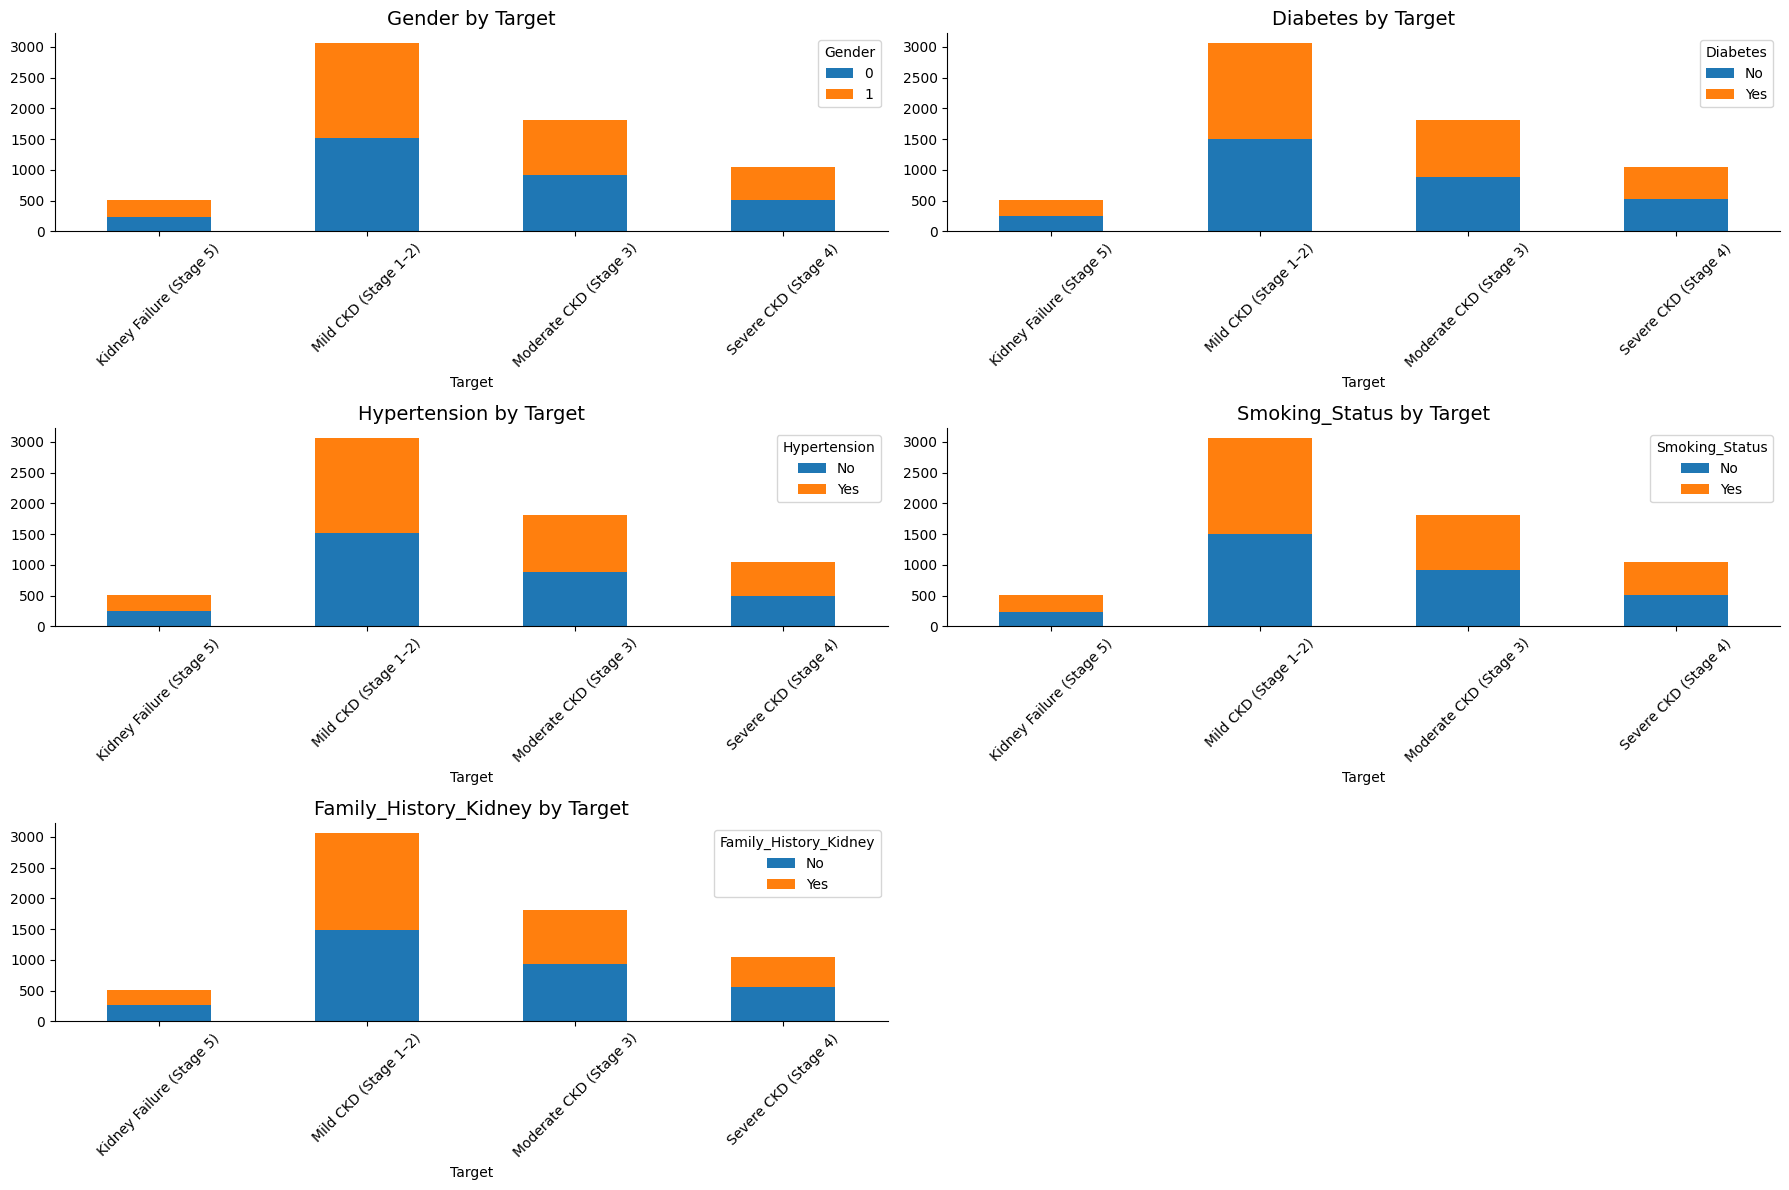

In [11]:
nrows, ncols = 3, 2

fig_h = nrows * 4.0   # try 2.4–3.0 depending on label length
fig_w = 18

fig, axarr = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), constrained_layout=True)
axes = axarr.ravel()

for i, cat_col in enumerate(cat_cols[1:]):
    (df[df['Target'] != 'Healthy Kidney']
     .groupby(['Target', cat_col])
     .size()
     .unstack(fill_value=0)   # categories become columns
     .plot(kind='bar', stacked=True, ax=axes[i]))


    axes[i].set_title(f"{cat_col} by Target", fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, nrows*ncols):
    axes[j].axis('off')

plt.tight_layout()
sns.despine()
plt.show()

For the categorical features, there are no obvious indicators that strongly help predict kidney problems.

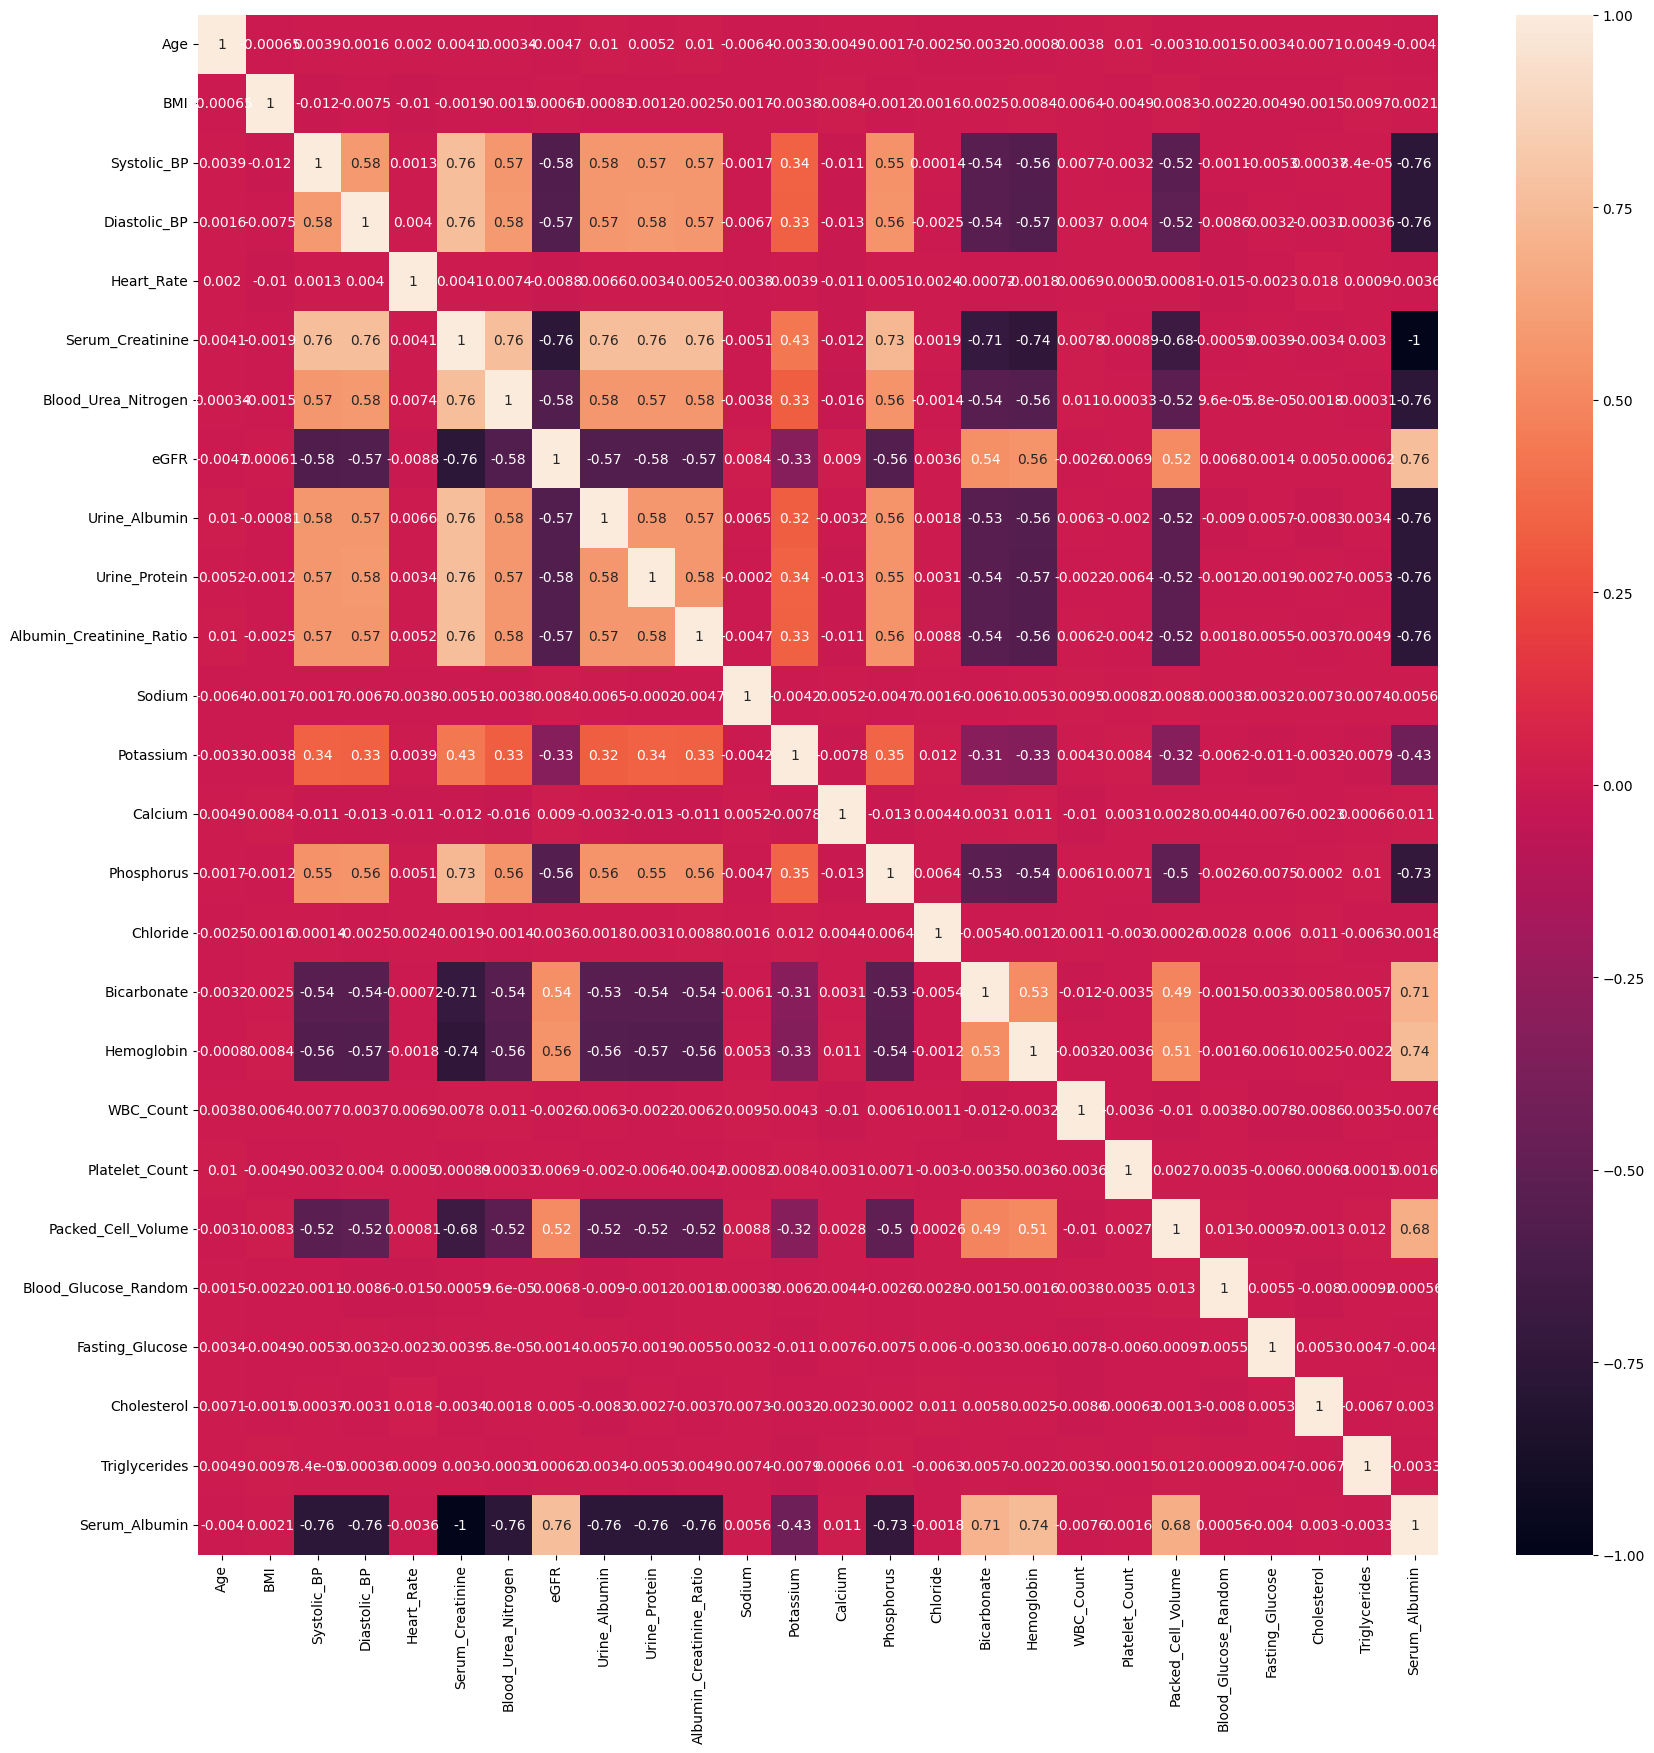

In [12]:
plt.figure(figsize=(20, 20))
sns.heatmap(df[num_cols].corr(method='spearman'), annot = True, vmin = -1, vmax = 1)
plt.show()

We used **Spearman correlation** because many of the features are skewed and may not have a linear relationship with each other. This analysis shows that there are strong relationships among several of the features.

# Step 4 - Prepare data for ML
Label encoding will be used to change categorical fields into numerical value

SMOTE will be used to balance kidney diseases

In [13]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

def get_mapping(label_encoder):
    mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    new_dict = dict([(value.item(0), key) for key, value in mapping.items()])
    return new_dict

le = LabelEncoder()

df_ml = df.copy(deep = True)

df_ml["Gender"] = df_ml["Gender"].astype("int64")
df_ml['Diabetes'] = le.fit_transform(df['Diabetes'])
diabetes_mapping = get_mapping(le)
df_ml['Hypertension'] = le.fit_transform(df['Hypertension'])
hypertension_mapping = get_mapping(le)
df_ml['Smoking_Status'] = le.fit_transform(df['Smoking_Status'])
smoking_mapping = get_mapping(le)
df_ml['Family_History_Kidney'] = le.fit_transform(df['Family_History_Kidney'])
family_mapping = get_mapping(le)
df_ml['Target'] = le.fit_transform(df['Target'])
target_mapping = get_mapping(le)

smote = SMOTE(sampling_strategy='all', random_state=42)
df_ml_input, df_ml_output = smote.fit_resample(df_ml.drop(['Target'], axis=1), df_ml['Target'])


In [14]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(df_ml_input, df_ml_output, stratify=df_ml_output, test_size=0.2, random_state=42)

**Very important!**

The ` stratify ` arguement splits in a way to preserve the class distribution.

<Axes: xlabel='count', ylabel='Target'>

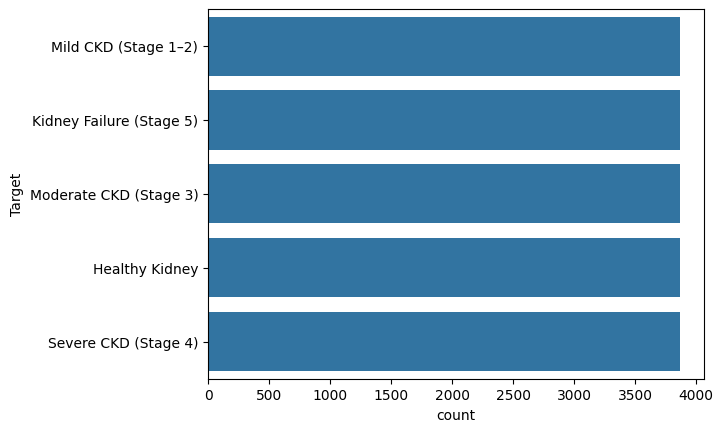

In [15]:
sns.countplot(data=y_test.replace(target_mapping))

In [16]:
print("We have {} training records".format(len(X_train)))
print("We have {} testing records".format(len(X_test)))

We have 77436 training records
We have 19359 testing records


### Or we can use cross validation which uses all of the folds!

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 5 - Hyperparameter tuning & Train ML

We will train KNN anf XGBoost to compare classification performance. 

In [18]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import clear_output

def objective(trial):
    params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 50),
            "weights":     trial.suggest_categorical("weights", ["uniform", "distance"]),
            "algorithm":   trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
            "leaf_size":   trial.suggest_int("leaf_size", 10, 60),
            "p":           trial.suggest_int("p", 1, 2),  # 1 = Manhattan, 2 = Euclidean
            "metric":      trial.suggest_categorical("metric", ["minkowski", "euclidean", "manhattan"]),
            }
    
    model = KNeighborsClassifier(**params)
    scores = cross_val_score(
        model, df_ml_input, df_ml_output,
        cv=cv,
        scoring='roc_auc_ovr',
        n_jobs=-1
    )    
    return scores.mean()  

 

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)
clear_output()

In [19]:
knn = KNeighborsClassifier(**study.best_params)
knn.fit(X_train, y_train)

KNeighborsClassifier(leaf_size=27, metric='manhattan', n_neighbors=10,
                     weights='distance')

In [20]:
from xgboost import XGBClassifier

def objective(trial):
    params = {
        'n_estimators'       : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'          : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'   : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'gamma'              : trial.suggest_float('gamma', 0.0, 1.0),
        'eval_metric'        : 'auc',
        'enable_categorical' : True,
        'verbosity'          : 0
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(
        model, df_ml_input, df_ml_output,
        cv=cv,
        scoring='roc_auc_ovr',
        n_jobs=-1
    )    
    return scores.mean()  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=True)
clear_output()

In [21]:
xg = XGBClassifier(**study.best_params)
xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6189490868128116, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.7800465991711394, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02525573855305703,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=903, n_jobs=None,
              num_parallel_tree=None, ...)

# Step 6 - Evaluation

## Let's evaluate KNN first

In [22]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, accuracy_score, auc
)

# Full probability matrix: (n_samples, n_classes)
val_proba = knn.predict_proba(X_test)

# Predicted class labels
val_preds = np.argmax(val_proba, axis=1)

print("=" * 50)
print("📊 FULL MULTICLASS EVALUATION REPORT")
print("=" * 50)

# ROC-AUC (One-vs-Rest)
print(
    f"ROC-AUC Score  : "
    f"{roc_auc_score(y_test, val_proba, multi_class='ovr', average='weighted'):.5f}"
)

print(f"Accuracy       : {accuracy_score(y_test, val_preds):.5f}")
print(f"F1 Score       : {f1_score(y_test, val_preds, average='weighted'):.5f}")

print("\n📋 Classification Report:")
print(classification_report(pd.Series(y_test).replace(target_mapping), pd.Series(val_preds).replace(target_mapping)))

📊 FULL MULTICLASS EVALUATION REPORT
ROC-AUC Score  : 0.99655
Accuracy       : 0.94617
F1 Score       : 0.94587

📋 Classification Report:
                          precision    recall  f1-score   support

          Healthy Kidney       0.97      0.78      0.86      3872
Kidney Failure (Stage 5)       1.00      1.00      1.00      3871
    Mild CKD (Stage 1–2)       0.81      0.97      0.88      3872
  Moderate CKD (Stage 3)       0.99      0.98      0.99      3872
    Severe CKD (Stage 4)       1.00      1.00      1.00      3872

                accuracy                           0.95     19359
               macro avg       0.95      0.95      0.95     19359
            weighted avg       0.95      0.95      0.95     19359



/tmp/ipykernel_17/297652293.py:56: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


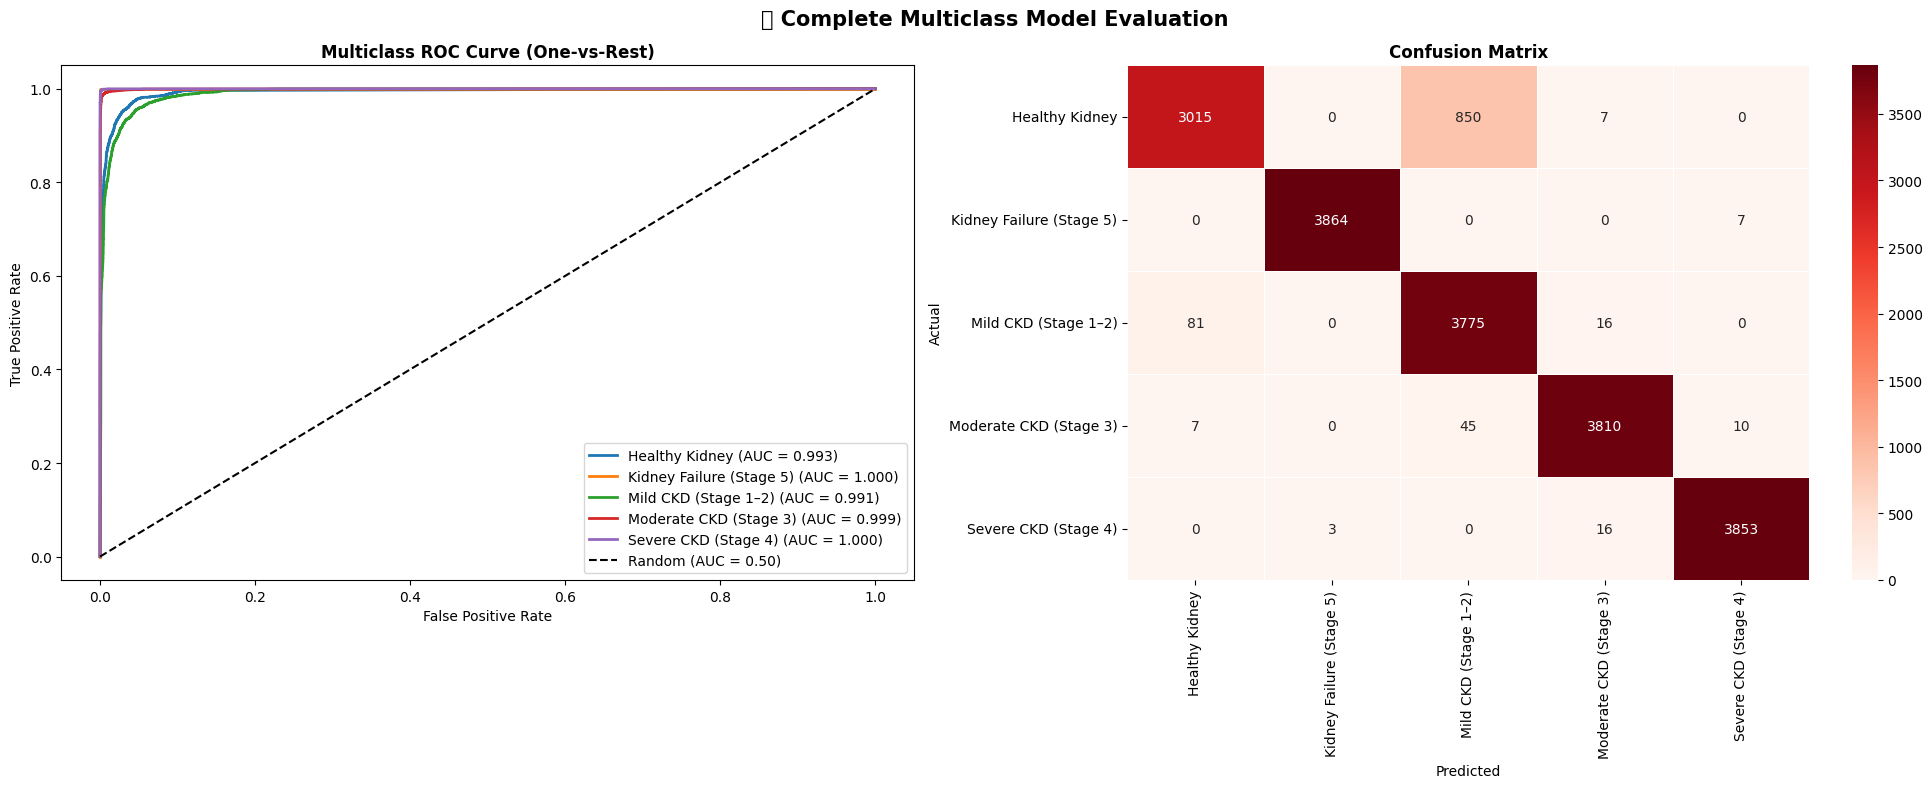

In [23]:
from sklearn.preprocessing import label_binarize

class_names = knn.classes_
n_classes = len(class_names)

y_test_bin = label_binarize(y_test, classes=class_names)
class_names = pd.Series(xg.classes_).replace(target_mapping)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# =============================
# Plot 1: Multiclass ROC (OvR)
# =============================
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr, tpr, lw=2,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

# Random baseline
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.50)")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Multiclass ROC Curve (One-vs-Rest)", fontweight="bold")
axes[0].legend(loc="lower right")

# =============================
# Plot 2: Confusion Matrix
# =============================
cm = confusion_matrix(y_test, val_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# =============================
# Final layout
# =============================
plt.suptitle("📊 Complete Multiclass Model Evaluation",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Model struggles with detecting Mild CKD. It had instances where it would predict those cases as Healthy Kidney.  

## Now let's compare it against XGBoost

In [24]:
# Full probability matrix: (n_samples, n_classes)
val_proba = xg.predict_proba(X_test)

# Predicted class labels
val_preds = np.argmax(val_proba, axis=1)

print("=" * 50)
print("📊 FULL MULTICLASS EVALUATION REPORT")
print("=" * 50)

# ROC-AUC (One-vs-Rest)
print(
    f"ROC-AUC Score  : "
    f"{roc_auc_score(y_test, val_proba, multi_class='ovr', average='weighted'):.5f}"
)

print(f"Accuracy       : {accuracy_score(y_test, val_preds):.5f}")
print(f"F1 Score       : {f1_score(y_test, val_preds, average='weighted'):.5f}")

print("\n📋 Classification Report:")
print(classification_report(pd.Series(y_test).replace(target_mapping), pd.Series(val_preds).replace(target_mapping)))

📊 FULL MULTICLASS EVALUATION REPORT
ROC-AUC Score  : 1.00000
Accuracy       : 1.00000
F1 Score       : 1.00000

📋 Classification Report:
                          precision    recall  f1-score   support

          Healthy Kidney       1.00      1.00      1.00      3872
Kidney Failure (Stage 5)       1.00      1.00      1.00      3871
    Mild CKD (Stage 1–2)       1.00      1.00      1.00      3872
  Moderate CKD (Stage 3)       1.00      1.00      1.00      3872
    Severe CKD (Stage 4)       1.00      1.00      1.00      3872

                accuracy                           1.00     19359
               macro avg       1.00      1.00      1.00     19359
            weighted avg       1.00      1.00      1.00     19359



/tmp/ipykernel_17/4107585154.py:62: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


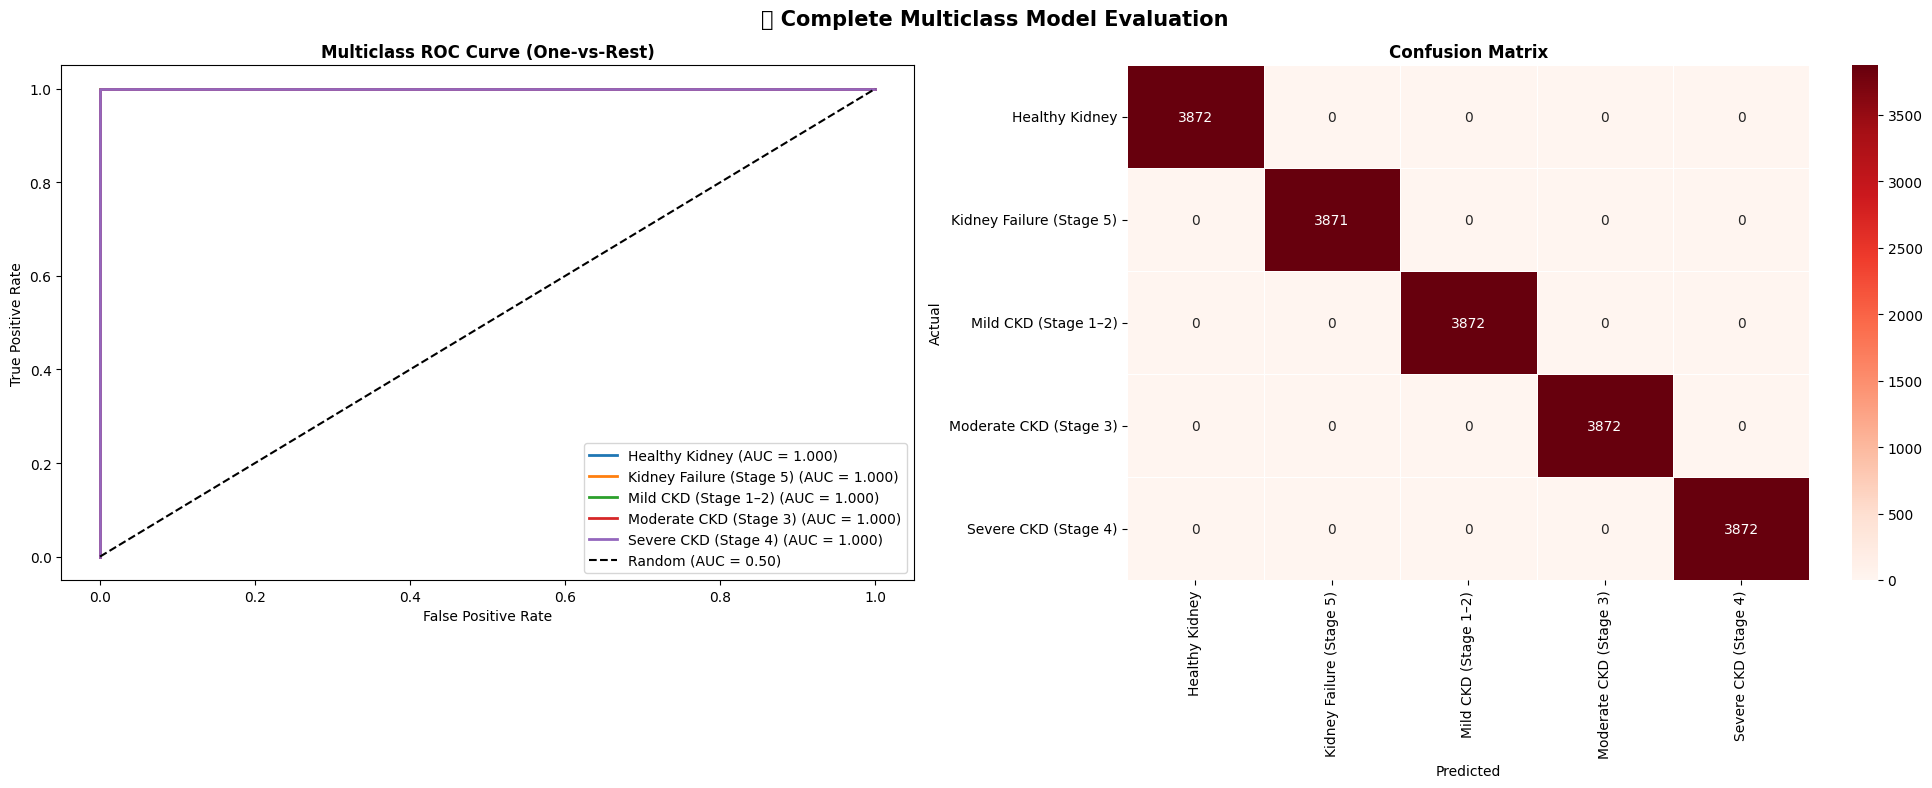

In [25]:

from sklearn.preprocessing import label_binarize

# -----------------------------
# Setup
# -----------------------------
class_names = xg.classes_
n_classes = len(class_names)

val_proba = xg.predict_proba(X_test)
val_preds = np.argmax(val_proba, axis=1)

y_test_bin = label_binarize(y_test, classes=class_names)
class_names = pd.Series(xg.classes_).replace(target_mapping)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# =============================
# Plot 1: Multiclass ROC (OvR)
# =============================
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr, tpr, lw=2,
        label=f"{cls} (AUC = {roc_auc:.3f})"
    )

# Random baseline
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random (AUC = 0.50)")

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Multiclass ROC Curve (One-vs-Rest)", fontweight="bold")
axes[0].legend(loc="lower right")

# =============================
# Plot 2: Confusion Matrix
# =============================
cm = confusion_matrix(y_test, val_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# =============================
# Final layout
# =============================
plt.suptitle("📊 Complete Multiclass Model Evaluation",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


### XGBoost achieves perfect score for all class. Maybe the dataset is too synthetic and does not reflect the real world accurately?

# Step 7 - Explainable AI with SHAP values 

It is not sufficient to tell patients that they have an illness. They also want to understand why the diagnosis was made and how it was reached.

SHAP values help address this by showing which features had the greatest influence on the model’s diagnostic decision.

In [26]:
import shap

explainer = shap.TreeExplainer(xg)
shap_values = explainer(X_test)

Class: Healthy Kidney


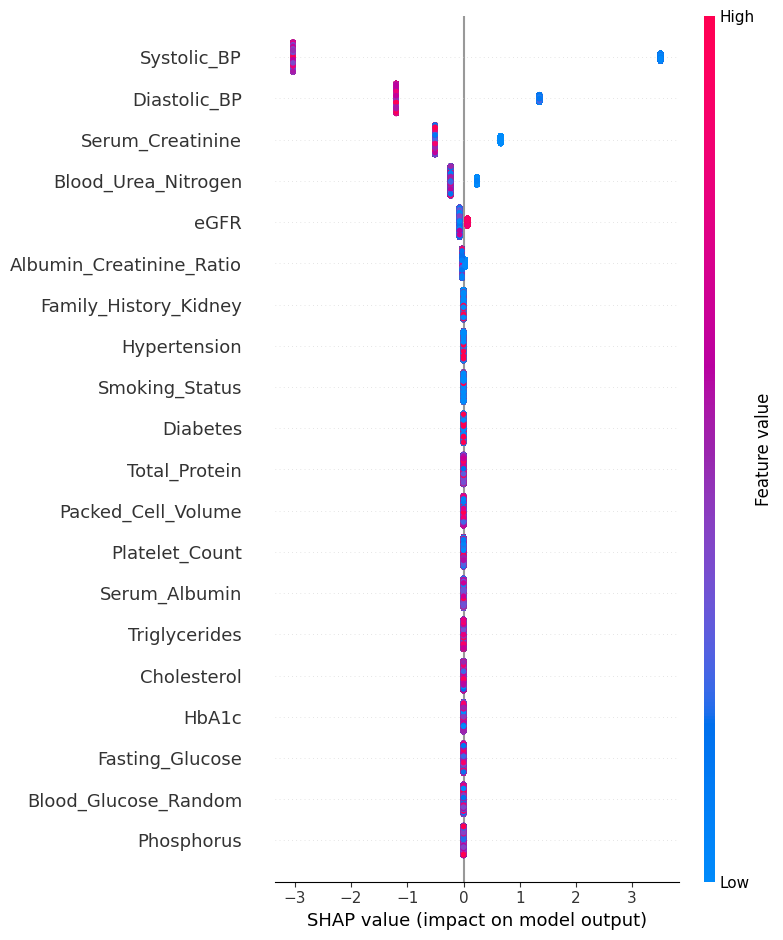

Class: Kidney Failure (Stage 5)


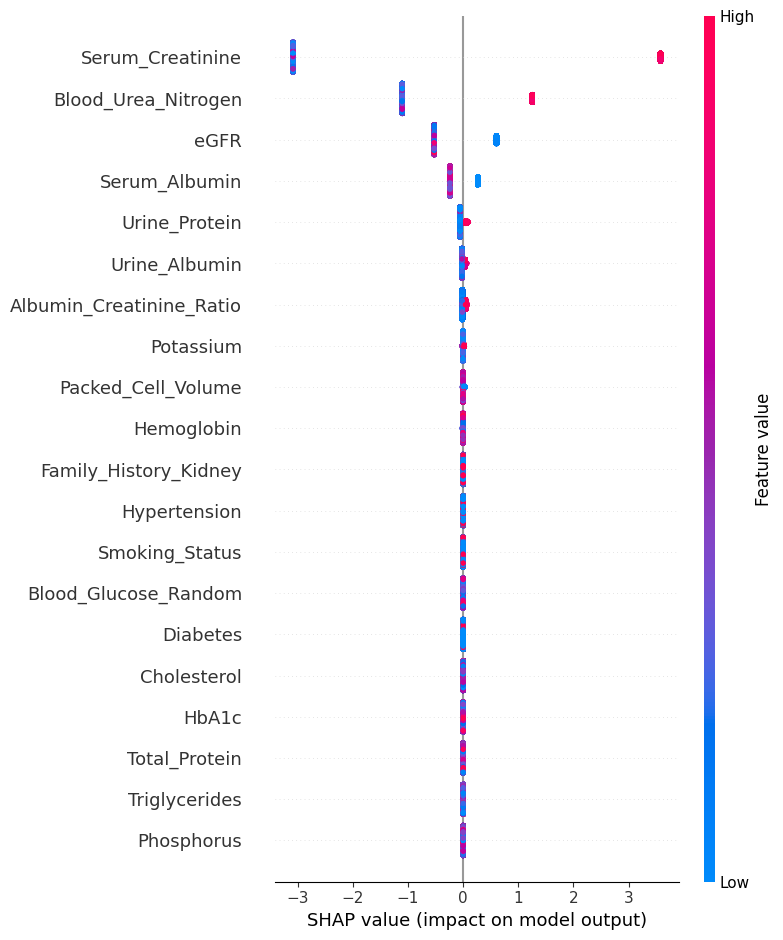

Class: Mild CKD (Stage 1–2)


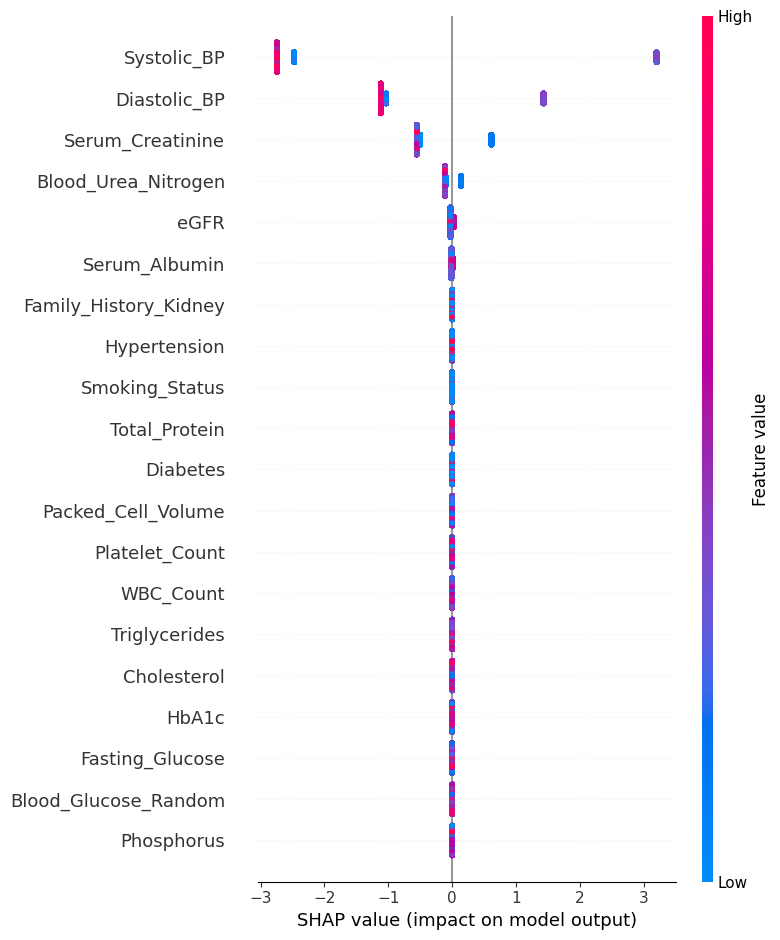

Class: Moderate CKD (Stage 3)


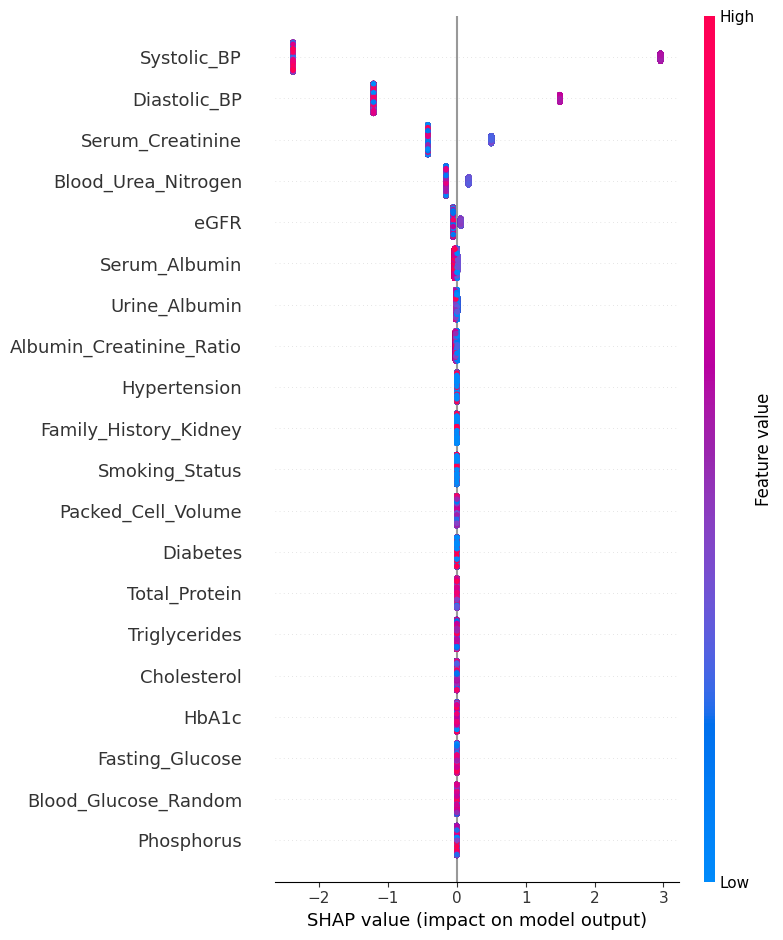

Class: Severe CKD (Stage 4)


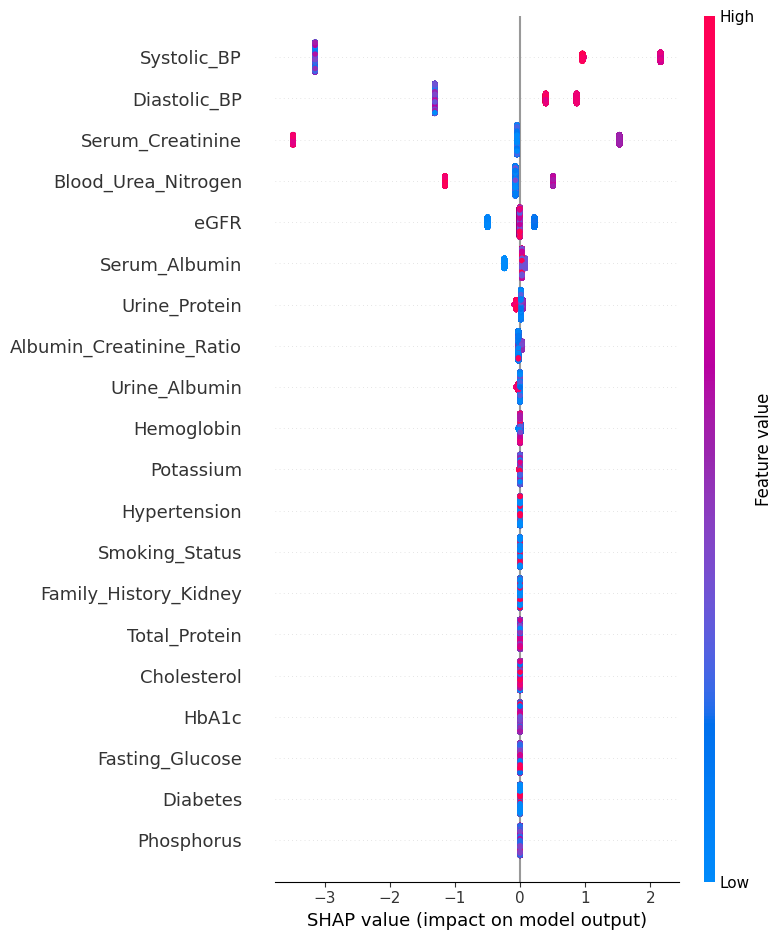

In [27]:
for x in target_mapping:
    print("Class:", target_mapping[x])
    shap.summary_plot(shap_values[:, :, x], X_test, feature_names=X_test.columns)

### Positive SHAP values enhance predictions, while negative SHAP values reduce them. Blue indicates low value, purple represents medium, and red signifies high value.

XGBoost uses about 5 of the 30+ features to determine the type of kidney disease. 

According to the SHAP summary, the following features are required for each class: 

1. Healthy Kidney:
   * Low diastolic and systolic BP
   * Low Serum creatinine and blood urea nitrogen
2. Mild CKD (Stage 1-2):
   * Medium diastolic and systolic BP
   * Low serum creatinine and blood urea nitrogen
3. Moderate CKD (Stage 3):
   * Medium-high diastolic and systolic BP
   * Low-medium serum creatinine, blood urea nitrogen and eGFR
4. Severe CKD (Stage 4):
   * High diastolic and systolic BP
   * Medium serum creatinine and blood urea nitrogen
   * Low eGFR
5. Kidney Failure (Stage 5):
    * High serum creatinine and blood urea nitrogen
    * Low eGFR and serum albumin

## Explaining the decision for a single patient

SHAP can also explain why a model assigned a classification to a single patient.

In [28]:
print("Let's pick a patient with a confirmed case of Stage 4 CKD")
record = df.iloc[[1]]
record

Let's pick a patient with a confirmed case of Stage 4 CKD


,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No


In [29]:
record["Gender"] = record["Gender"].astype("int64")
record['Diabetes'] = le.fit_transform(record['Diabetes'])
record['Hypertension'] = le.fit_transform(record['Hypertension'])
record['Smoking_Status'] = le.fit_transform(record['Smoking_Status'])
record['Family_History_Kidney'] = le.fit_transform(record['Family_History_Kidney'])
record.drop(['Target'], axis=1, inplace=True)

/tmp/ipykernel_17/1539258262.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  record["Gender"] = record["Gender"].astype("int64")
/tmp/ipykernel_17/1539258262.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  record['Diabetes'] = le.fit_transform(record['Diabetes'])
/tmp/ipykernel_17/1539258262.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

In [30]:
val_proba = xg.predict_proba(record)
val_preds = np.argmax(val_proba, axis=1)
answer = pd.Series(val_preds).replace(target_mapping).values[0]
print(f"XGBoost correctly predicted as: {answer}")
print("But how?")

XGBoost correctly predicted as: Severe CKD (Stage 4)
But how?


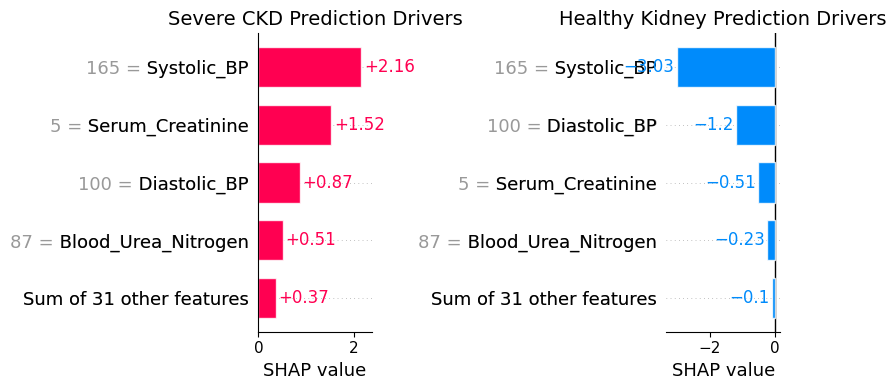

In [31]:
import matplotlib.pyplot as plt
import shap

shap.initjs()

explainer = shap.TreeExplainer(xg)
shap_values = explainer(record)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))  # wider AND taller

# Severe CKD (class 4)
plt.sca(axes[0])
shap.plots.bar(shap_values[0, :, 4], max_display=5, show=False)
axes[0].set_title("Severe CKD Prediction Drivers", fontsize=14)

# Healthy kidney (class 0)
plt.sca(axes[1])
shap.plots.bar(shap_values[0, :, 0], max_display=5, show=False)
axes[1].set_title("Healthy Kidney Prediction Drivers", fontsize=14)

plt.tight_layout()
plt.show()

### This plot compares SHAP values for severe CKD and healthy kidneys. It shows that all features positively contribute to the severe CKD classification. Doctors can explain to patients that specific values like systolic blood pressure and serum creatinine indicate their diagnosis of Stage 4 CKD. They can also compare these values to those of healthy individuals, highlighting that many of the patient's features are outside the normal range.